# ANALYSE EXPLORATOIRE ÉCONOMÉTRIE

https://www.onisr.securite-routiere.gouv.fr/dataviz

L’analyse exploratoire est intégrée au notebook économétrique car elle permet d’identifier les relations empiriques entre les caractéristiques des accidents et leur gravité, qui sont ensuite formalisées et testées à l’aide de modèles paramétriques.

# IMPORTATIONDES LIBRAIRIES

In [54]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import prince
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency
from scipy.stats import jarque_bera
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.pylab import rcParams
from scipy.stats import kendalltau, spearmanr, chi2_contingency, kruskal, wilcoxon, mannwhitneyu
from scipy.stats.contingency import association
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from prince import CA, MCA, FAMD, PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
rcParams['figure.figsize'] = 5,3
import statsmodels.api as sm
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve,accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay

## Importation de la base de donnée 

In [2]:
os.getcwd()

'/Users/gerard/Desktop/DU_BIGDATA/projet_tuteures/Econometrie/Parametrique'

In [55]:
# Chargement des bases de caractéristiques (X)
df_final = pd.read_csv('../../data_bases/base_complete.csv', sep=';', encoding='utf-8-sig') #df = pd.read_csv("base_complete_2021.csv", sep=';')
df_final.head()

,Num_Acc,jour,mois,an,hrmn,lum,com,agg,int,atm,...,num_veh_y,senc,catv,obs,obsm,choc,manv,motor,occutc,target
0,202100037733,28,5,2021,14:15,1,CC_97407,2,2,1,...,B01,3,1,0,2,8,1,5,0,0
1,202100037733,28,5,2021,14:15,1,CC_97407,2,2,1,...,A01,3,7,0,9,1,1,1,0,0
2,202100049382,2,3,2021,10:59,1,CC_63113,2,1,1,...,A01,1,10,0,2,1,2,1,0,0
3,202100049382,2,3,2021,10:59,1,CC_63113,2,1,1,...,B01,1,7,0,2,4,2,1,0,0
4,202100038891,20,5,2021,16:50,1,CC_88160,2,2,1,...,A01,1,7,0,2,1,1,1,0,0


## Fonctions utiles

In [56]:
# Pipeline d'audit et diagnostic des variables 

def analyse_df(df_final):

    for var in df_final.columns:
        
        print("\n" + "="*50)
        print(f"ANALYSE DE LA VARIABLE : {var}")
        print("="*50)

        print(f"Type : {df_final[var].dtype}")
        print(f"Valeurs manquantes : {df_final[var].isna().sum()}")

        # Variables numériques
        if df_final.api.types.is_numeric_dtype(df_final[var]):

            print("\nStatistiques descriptives :")
            print(df_final[var].describe())

        # Variables catégorielles
        else:

            counts = df_final[var].value_counts()

            print("\nTop modalités :")
            print(counts.head(10))

# 1 - ANALYSE EXPLORATOIRE DES DONNÉES (EDA)

## Analyse descriptive des données 

In [57]:
df_final.info()
df_final.isna().sum()
df_final.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126097 entries, 0 to 126096
Data columns (total 55 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      126097 non-null  int64  
 1   jour         126097 non-null  int64  
 2   mois         126097 non-null  int64  
 3   an           126097 non-null  int64  
 4   hrmn         126097 non-null  object 
 5   lum          126097 non-null  int64  
 6   com          126097 non-null  object 
 7   agg          126097 non-null  int64  
 8   int          126097 non-null  int64  
 9   atm          126097 non-null  int64  
 10  col          126097 non-null  int64  
 11  adr          124742 non-null  object 
 12  lat          126097 non-null  object 
 13  long         126097 non-null  object 
 14  dep          126097 non-null  object 
 15  catr         126097 non-null  int64  
 16  voie         117057 non-null  object 
 17  v1           126097 non-null  int64  
 18  v2           126097 non-

np.int64(0)

### Analyse univariée

Visualiser la colonne de la variable cible : **grav** (avec les codes 1, 2, 3, 4) est difficile à interpréter pour un lecteur. C'est pour cela que :

Je définie cette colonne **grav** en une colonne **target** (**0 = Léger, 1 = Grave**), ce qui permet de voir le premier graphique avec la proportion réelle du risque de notre étude.

C'est le point de départ de mon argumentation : "Dans la base, **X%** des accidents sont **graves** ou **X%** des accidents sont **moins grave**".

In [58]:
# 1 = Indemne, 2 = Tué, 3 = Blessé hospitalisé, 4 = Blessé léger

# On regroupe 2 et 3 pour définir la gravité (Grave) et 1 et 4 pour definir (moins grave)

df_final['target'] = df_final['grav'].apply(lambda x: 1 if x in [2, 3] else 0)

# Vérification de la création

print(df_final['target'].value_counts())

target
0    103790
1     22307
Name: count, dtype: int64


**Commentaire :** 

L'étude de la gravité repose sur la variable binaire **`target`**, construite à partir des données de l'accidentalité 2021. Cette variable constitue le cœur de notre analyse économétrique.

Afin de modéliser la probabilité de survenue d'un accident corporel sérieux, nous avons procédé à un regroupement des modalités de la variable d'origine `grav` :
* **Target = 0 (Non Grave) :** Regroupe les usagers **Indemnes** et les **Blessés légers** sont de 103 790 avec **82,31 %**.
* **Target = 1 (Grave) :** Regroupe les usagers **Tués** et les **Blessés hospitalisés** sont de 22 307 avec **17,69 %**.

On observe un déséquilibre entre les classes (environ 1/5ème de "Grave"). En économétrie, ce ratio est suffisant pour une estimation par **Maximum de Vraisemblance (Logit)**.
Avec plus de 22 000 observations pour les accidents graves, le modèle dispose d'une puissance statistique élevée, garantissant des **p-values** fiables et des erreurs-types réduites pour les coefficients.
L'enjeu sera d'isoler les facteurs de risque spécifiques (vitesse, défaut de protection) qui augmentent significativement la probabilité d'appartenir à la classe 1.

In [59]:
# Calcul de l'âge au moment de l'accident

# On soustrait l'année de naissance de l'année de l'accident
df_final['age'] = df_final['an'] - df_final['an_nais']

# Liste finale des variables pertinentes 
features = [
    'target', 'age', 'sexe', 'trajet', 'secu1', 
    'lum', 'atm', 'agg', 'catr', 'vma', 'surf', 
    'catv', 'motor', 'col'
]

# Création du DataFrame d'étude (on ne garde que l'essentiel)
df_eco = df_final[features].copy()

# Nettoyage des valeurs manquantes
df_eco = df_eco.dropna()

print(f"Dimensions du dataset économétrique : {df_eco.shape}")
print(df_eco[['age', 'target']].head()) # Petit check pour vérifier

Dimensions du dataset économétrique : (126097, 14)
   age  target
0   51       0
1   23       0
2   42       0
3   26       0
4   90       0


**Commentaire :**

Le dataset final d'étude se compose de **126 097** observations et **14** variables explicatives. Cette sélection rigoureuse permet de se concentrer sur les dimensions critiques de l'accident (usager, véhicule, environnement).

La création de la variable **age** est ici centrale : l'aperçu montre une grande diversité générationnelle **(de 23 à 90 ans)**, ce qui est crucial pour modéliser la vulnérabilité des usagers. Ce dataset purifié constitue une base saine pour l'entraînement de notre modèles de classification.

## Analyse bivariée

**Relation : target vs cols_etude (variables qui influences les accidents)**

**#A8DADC (Bleu clair) :** Représente généralement la classe **0 (Léger)**.

**#E63946 (Rouge) :** Représente la classe **1 (Grave)**, donc Le rouge attire immédiatement l'œil sur les situations les plus dangereuses.

**kind='bar'** définit le type de graphique, cela permet de comparer des catégories (ex: les types de météo atm ou de routes catr).

**stacked=True** cela permet d'empiler les catégories de la **target** les unes sur les autres au lieu de les mettre côte à côte. Puisque j'ai normalisé les données (normalize='index' dans le crosstab), chaque barre fait exactement 100% de haut. Cela nous montre d'un coup d'œil la proportion relative de gravité pour chaque modalité.

**ax=plt.gca()** Cela signifie "Get Current Axis". Ce qui demande à Pandas de dessiner le graphique sur la figure Matplotlib qui est déjà ouverte et permet de garder le contrôle sur la personnalisation (titres, étiquettes) avant d'afficher le résultat final.


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : SEXE vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
sexe                
1       81.25  18.75
2       84.60  15.40
3       70.00  30.00


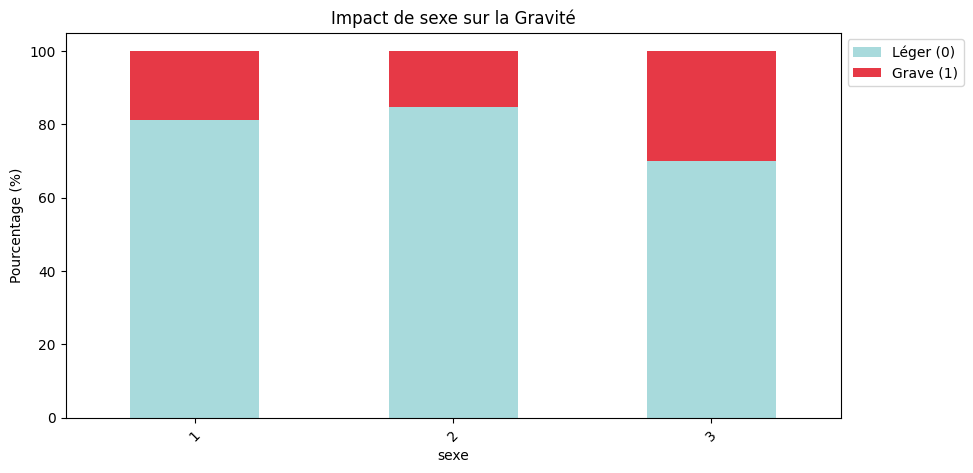


══════════════════════════════════════════════════
══════ ANALYSE BIVARIÉE : TRAJET vs TARGET ═══════

Pourcentage de gravité par modalité :
target      0      1
trajet              
-1      85.51  14.49
 0      85.28  14.72
 1      84.72  15.28
 2      83.76  16.24
 3      76.74  23.26
 4      93.05   6.95
 5      75.97  24.03
 9      85.87  14.13


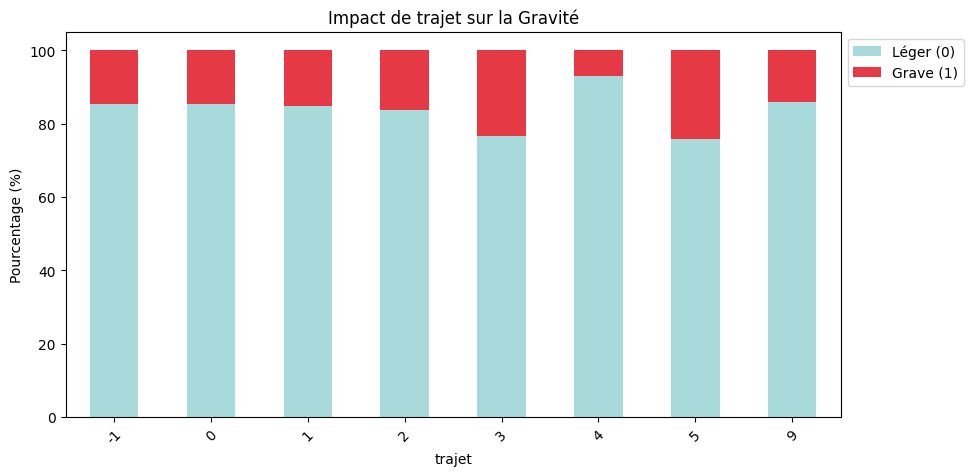


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : SECU1 vs TARGET ═══════

Pourcentage de gravité par modalité :
target       0      1
secu1                
-1       76.60  23.40
 0       62.50  37.50
 1       90.21   9.79
 2       67.23  32.77
 3       91.11   8.89
 4       45.33  54.67
 5       54.17  45.83
 6       27.19  72.81
 7      100.00   0.00
 8       82.48  17.52
 9       66.06  33.94


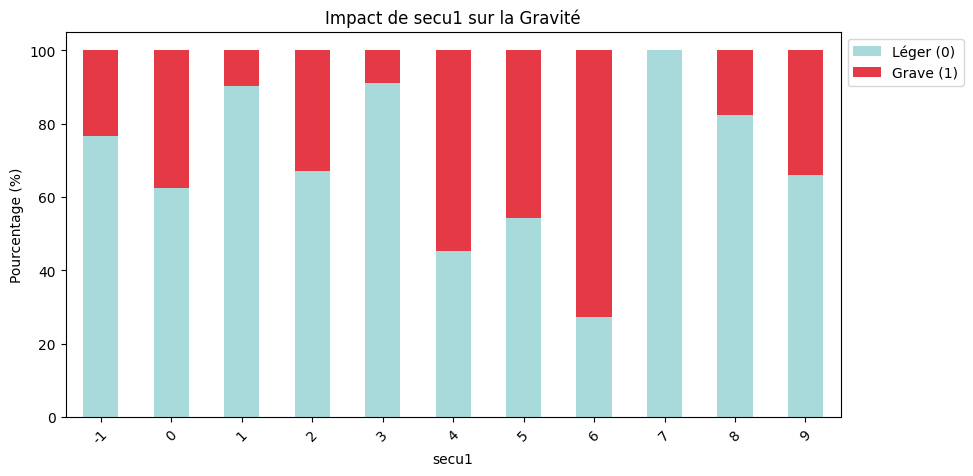


══════════════════════════════════════════════════
════════ ANALYSE BIVARIÉE : LUM vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
lum                 
1       83.19  16.81
2       79.69  20.31
3       71.66  28.34
4       81.03  18.97
5       86.13  13.87


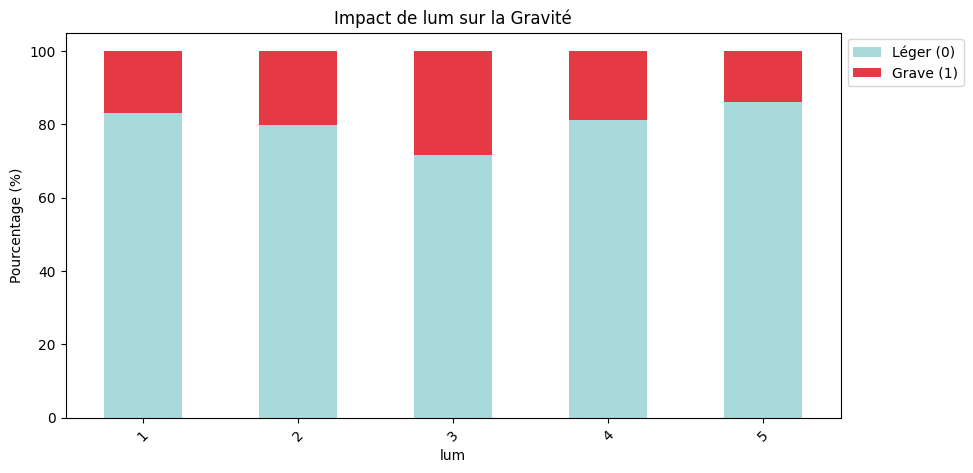


══════════════════════════════════════════════════
════════ ANALYSE BIVARIÉE : ATM vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
atm                 
-1      78.57  21.43
 1      82.21  17.79
 2      85.34  14.66
 3      82.48  17.52
 4      81.46  18.54
 5      71.72  28.28
 6      68.38  31.62
 7      75.29  24.71
 8      83.05  16.95
 9      73.90  26.10


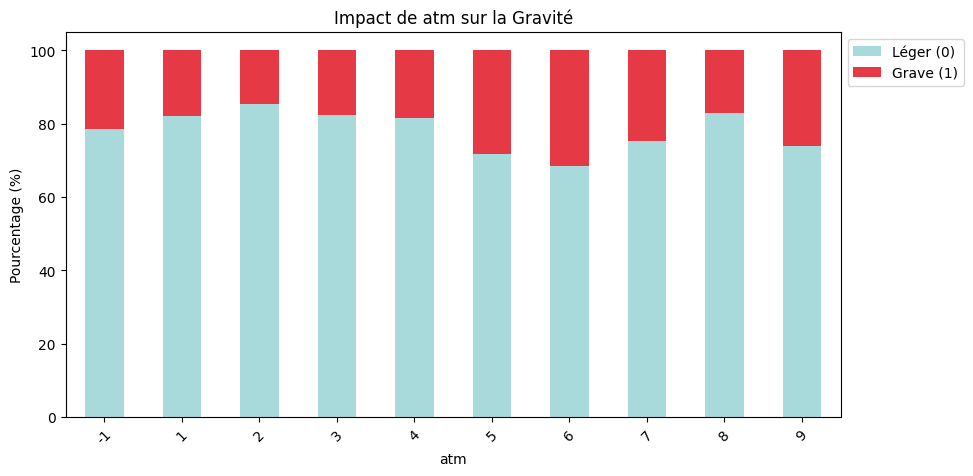


══════════════════════════════════════════════════
════════ ANALYSE BIVARIÉE : AGG vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
agg                 
1       74.58  25.42
2       87.03  12.97


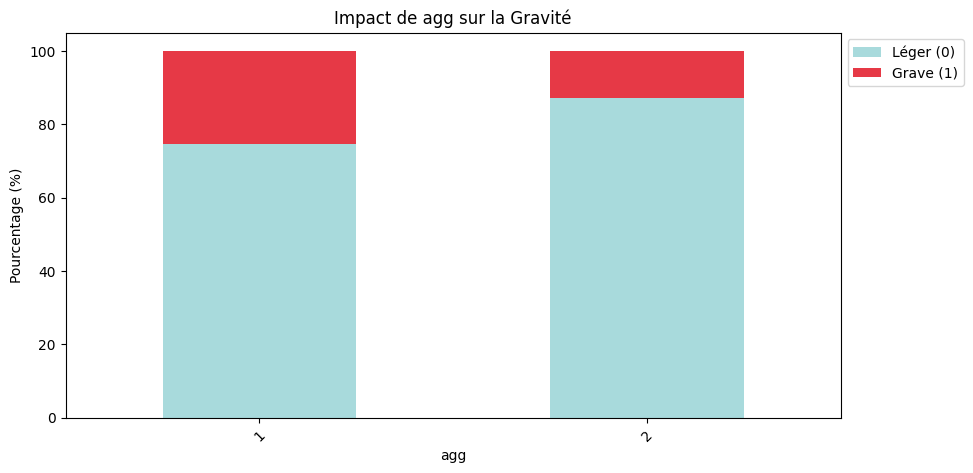


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : CATR vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
catr                
1       90.33   9.67
2       80.55  19.45
3       73.49  26.51
4       88.11  11.89
5       73.33  26.67
6       80.74  19.26
7       83.73  16.27
9       76.85  23.15


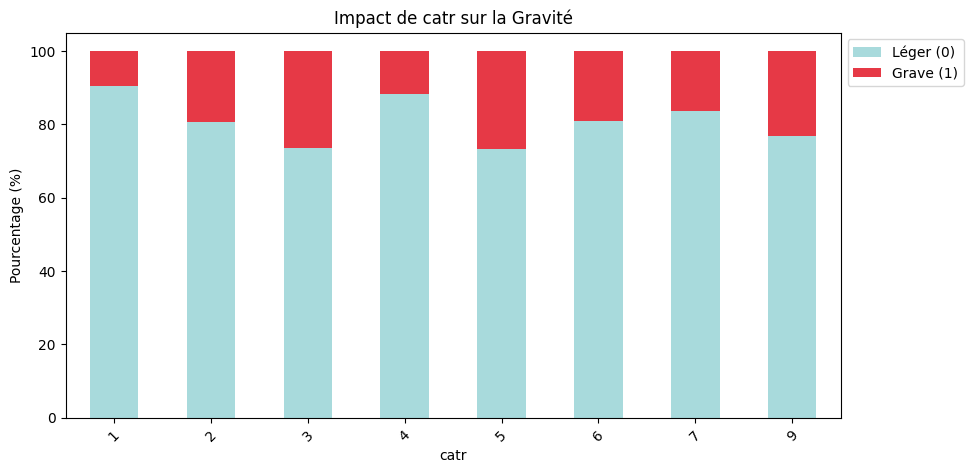


══════════════════════════════════════════════════
════════ ANALYSE BIVARIÉE : VMA vs TARGET ════════

Pourcentage de gravité par modalité :
target       0       1
vma                   
-1       65.06   34.94
 1       83.33   16.67
 2       87.50   12.50
 3      100.00    0.00
 5       85.00   15.00
 6      100.00    0.00
 8      100.00    0.00
 9      100.00    0.00
 10      85.33   14.67
 12     100.00    0.00
 15      95.92    4.08
 20      82.94   17.06
 25      92.50    7.50
 30      89.37   10.63
 40      67.65   32.35
 45      82.86   17.14
 50      86.25   13.75
 55       0.00  100.00
 60      64.61   35.39
 70      82.25   17.75
 75      33.33   66.67
 80      61.15   38.85
 90      84.91   15.09
 100     80.65   19.35
 110     88.12   11.88
 130     78.44   21.56
 140     50.00   50.00
 180     50.00   50.00
 300    100.00    0.00
 500     91.67    8.33
 501     50.00   50.00
 502    100.00    0.00
 520    100.00    0.00
 700    100.00    0.00
 770    100.00    0.00
 900   

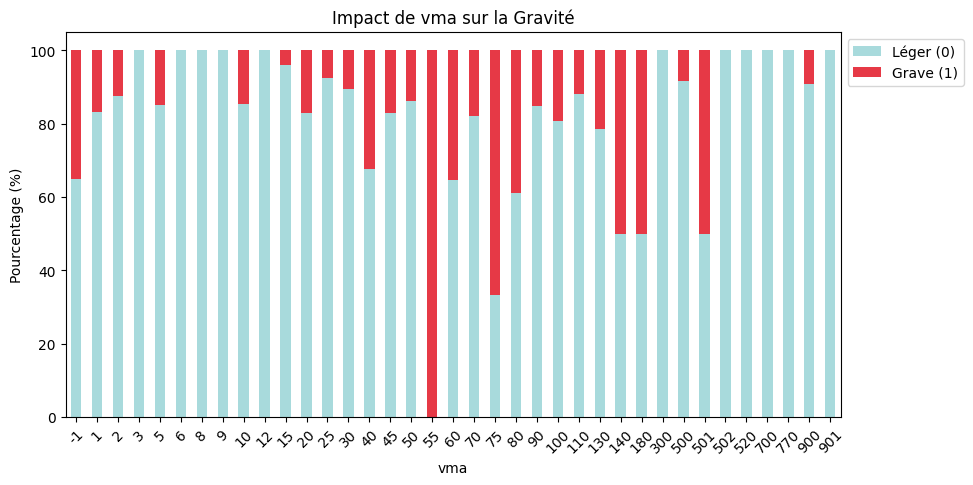


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : SURF vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
surf                
-1      73.08  26.92
 1      82.20  17.80
 2      83.74  16.26
 3      76.77  23.23
 4      81.48  18.52
 5      81.32  18.68
 6      54.32  45.68
 7      71.43  28.57
 8      82.22  17.78
 9      62.98  37.02


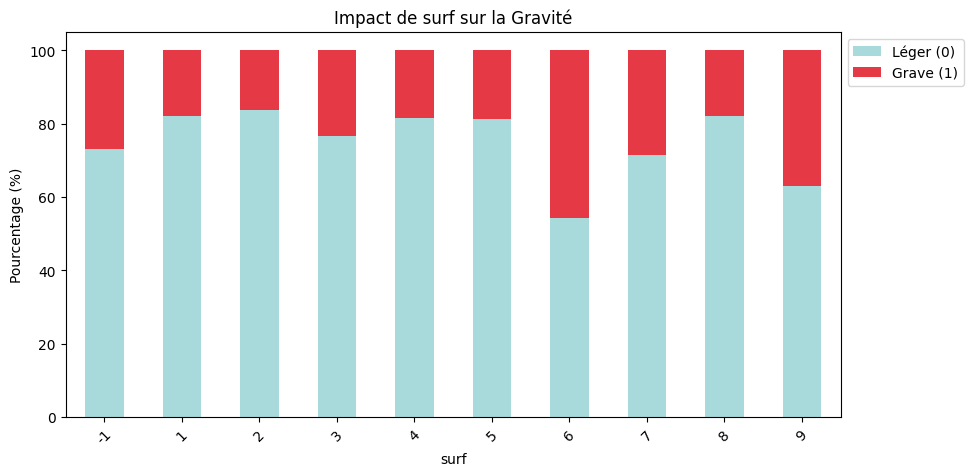


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : CATV vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
catv                
-1      50.00  50.00
 0      73.53  26.47
 1      73.24  26.76
 2      62.89  37.11
 3      81.75  18.25
 7      86.32  13.68
 10     89.81  10.19
 13     93.95   6.05
 14     89.68  10.32
 15     89.48  10.52
 16     80.56  19.44
 17     87.55  12.45
 20     85.48  14.52
 21     80.20  19.80
 30     83.76  16.24
 31     64.34  35.66
 32     77.98  22.02
 33     56.40  43.60
 34     72.27  27.73
 35     31.82  68.18
 36     39.57  60.43
 37     95.19   4.81
 38     91.25   8.75
 39     68.33  31.67
 40     90.69   9.31
 41     77.78  22.22
 42     66.67  33.33
 43     81.19  18.81
 50     84.88  15.12
 60     83.73  16.27
 80     74.22  25.78
 99     83.65  16.35


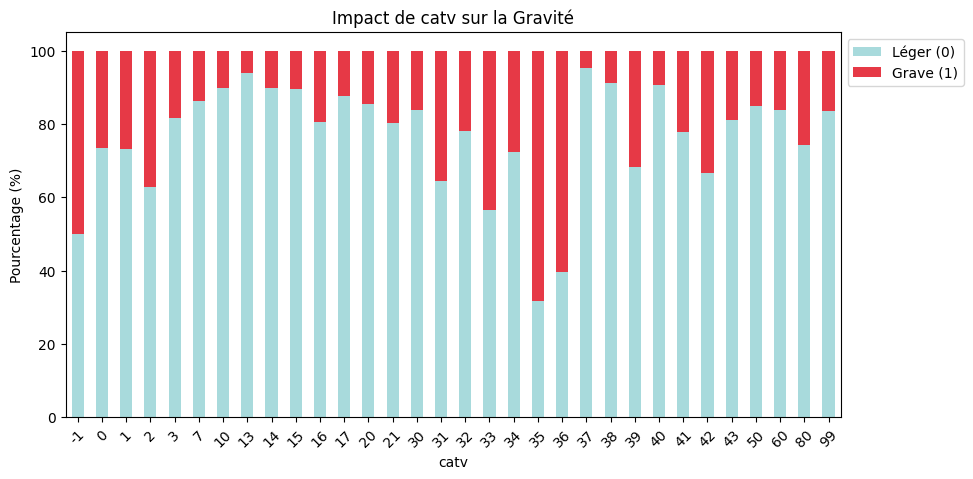


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : MOTOR vs TARGET ═══════

Pourcentage de gravité par modalité :
target      0      1
motor               
-1      81.99  18.01
 0      83.82  16.18
 1      82.40  17.60
 2      91.83   8.17
 3      84.84  15.16
 4      80.00  20.00
 5      73.88  26.12
 6      76.61  23.39


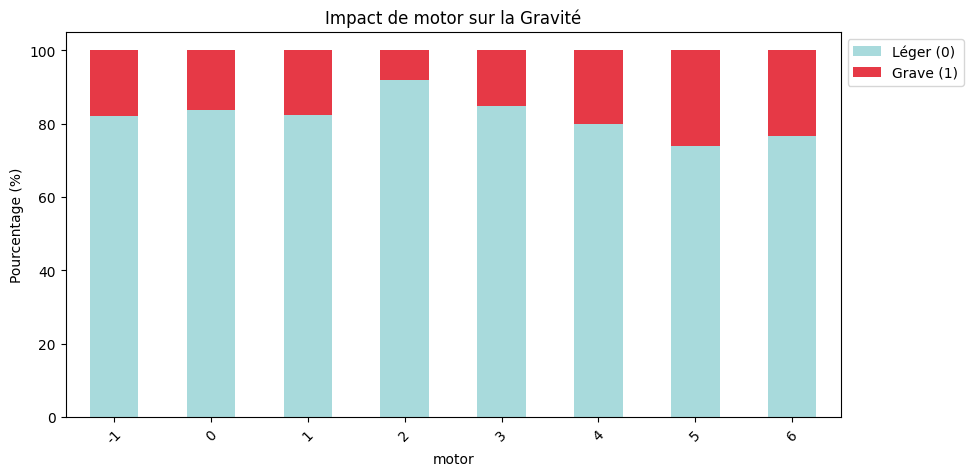


══════════════════════════════════════════════════
════════ ANALYSE BIVARIÉE : COL vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
col                 
-1      66.67  33.33
 1      73.12  26.88
 2      90.97   9.03
 3      87.13  12.87
 4      95.04   4.96
 5      87.10  12.90
 6      74.78  25.22
 7      64.12  35.88


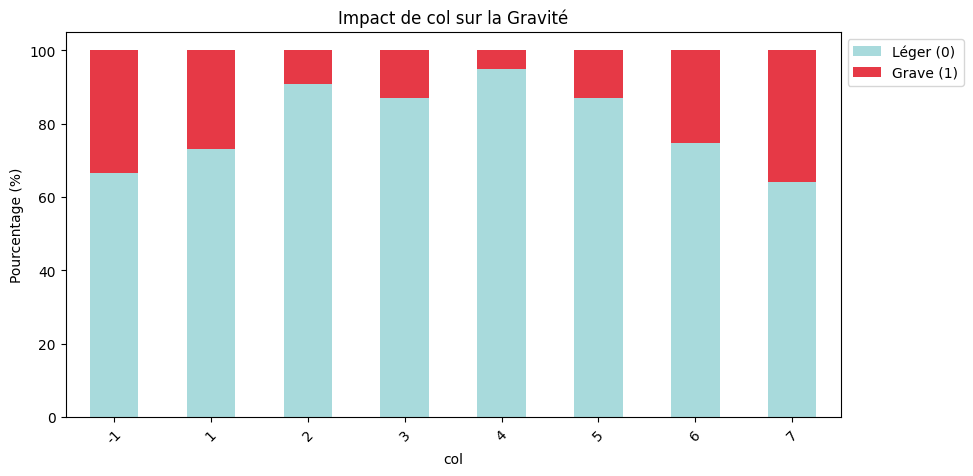


══════════════════════════════════════════════════
═════ ANALYSE BIVARIÉE : AGE_GROUP vs TARGET ═════

Pourcentage de gravité par modalité :
target         0      1
age_group              
0-18       78.67  21.33
18-25      83.20  16.80
25-45      86.05  13.95
45-65      81.88  18.12
65+        71.58  28.42


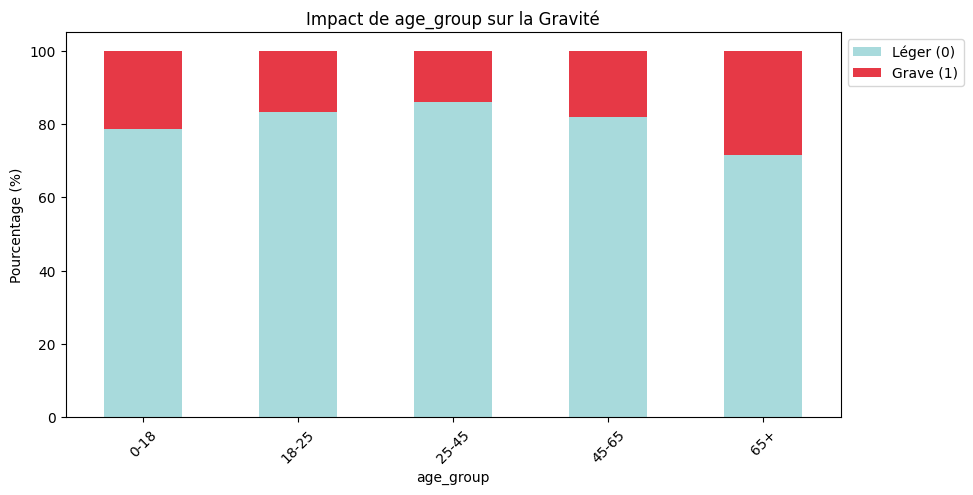

In [60]:
# 1. Préparation rapide : on groupe l'âge en tranches pour qu'il soit lisible
df_eco['age_group'] = pd.cut(df_eco['age'], bins=[0, 18, 25, 45, 65, 100], labels=['0-18', '18-25', '25-45', '45-65', '65+'])

def analyse_bivariee(df_final, target_col):
    # On itère sur les colonnes pertinentes (on remplace 'age' par 'age_group')
    for var in [c for c in df_final.columns if c not in [target_col, 'age']]:
        print("\n" + "═"*50)
        print(f" ANALYSE BIVARIÉE : {var.upper()} vs {target_col.upper()} ".center(50, "═"))
        
        ct = pd.crosstab(df_final[var], df_final[target_col], normalize='index') * 100
        print(f"\nPourcentage de gravité par modalité :\n{ct.round(2)}")
        
        plt.figure(figsize=(10, 5))
        ct.plot(kind='bar', stacked=True, color=['#A8DADC', '#E63946'], ax=plt.gca())
        plt.title(f"Impact de {var} sur la Gravité")
        plt.ylabel("Pourcentage (%)")
        plt.legend(["Léger (0)", "Grave (1)"], loc='upper left', bbox_to_anchor=(1, 1))
        plt.xticks(rotation=45)
        plt.show()

# 2. Lancement
analyse_bivariee(df_eco, 'target')

**Commentaire :**

L'analyse bivariée nous permet d'identifier les facteurs qui augmentent la proportion d'accidents graves (Target = 1). Voici les enseignements majeurs :

1. L'environnement (Lumière et Météo)
Luminosité (lum) : Le risque est maximal la nuit. En modalité 3 (Nuit sans éclairage public), le taux de gravité grimpe à 28,34 %, contre seulement 16,81 % en plein jour.

Météo (atm) : Les conditions extrêmes sont les plus dangereuses. Le brouillard (modalité 5), les fortes pluies (modalité 6) et Chaussée boueuse (surface 6) affichent des taux de gravité respectif de 28,28 %, 31,62 % 45,68 %.

2. L'infrastructure (Milieu et Type de route)
Milieu (agg) : C'est un facteur majeur. En zone rurale (hors agglomération, agg=1), 25,42 % des accidents sont graves, soit deux fois plus qu'en ville (12,97 %). La vitesse y est sans doute pour beaucoup.

Type de route (catr) : Les routes départementales (categorie 3) est de 26,51 % et les voies communales sont très contrastées. Les accidents sur les routes de type "autre" (5) ou "départementales" sont nettement plus sévères  de 12,96 % et 25,42 % que sur autoroute (1) 9,67 %, où la sécurité passive est meilleure.

3. Les facteurs humains et véhicules
Sexe (sexe) : Les hommes (1) présentent un taux de gravité légèrement plus élevé (18,75 %) que les femmes (2 : 15,40 %). Les Seniors (65+) : 28,42 % et les Jeunes (0–18 ans) : 1,33 %. 

Type de véhicule (catv) : Les contrastes sont massifs. Les deux-roues motorisés (modalités 35 et 36) affichent des taux de gravité records (plus de 60 %), illustrant la vulnérabilité de ces usagers.

Type de choc (col) : Les collisions de type "choc frontal" (1) ou "autre" (7) sont beaucoup plus graves (jusqu'à 35 %) que les chocs arrières (4) qui ne sont graves que dans 4,96 % des cas.

4. État de la route (surf)
La présence de "boue" (6) ou de "flaques d'eau" (9) augmente considérablement la gravité, avec un pic à 45,68 % pour la boue, soulignant l'importance de l'adhérence.

Les facteurs les plus déterminants de la gravité combinent : **Conditions externes défavorables** (nuit, météo, chaussée), **Environnement routier** (zones rurales, routes secondaires), **Vulnérabilité humaine** (âge, protection), **Type de collision et véhicule**.

## Heatmap de corrélations

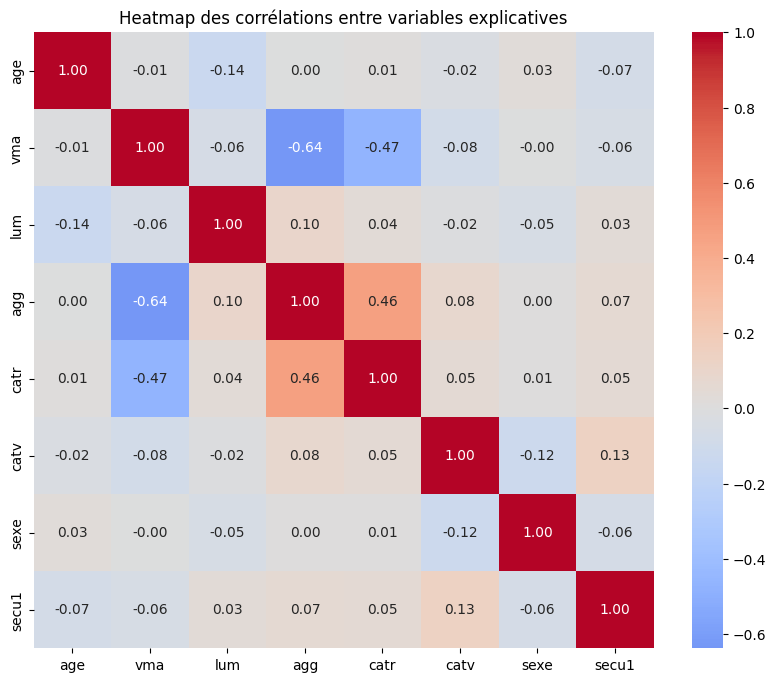

In [62]:
# Création de l'âge si nécessaire
if 'age' not in df_final.columns and 'an_nais' in df_final.columns:
    df_final['age'] = 2021 - df_final['an_nais']

# Sélection des variables numériques / ordinales pertinentes
variables_num = [
    'age',      # si déjà créée
    'vma',
    'lum',
    'agg',
    'catr',
    'catv',
    'sexe',
    'secu1'
]

# Suppression des valeurs manquantes
df_corr = df_final[variables_num].dropna()

# Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Heatmap des corrélations entre variables explicatives")
plt.show()

La **heatmap des corrélations** met en évidence une structure globale de faible corrélation entre la majorité des variables explicatives, ce qui indique une absence générale de multicolinéarité sévère. La plupart des coefficients de corrélation sont proches de **zéro**, suggérant que les variables capturent des dimensions complémentaires de la situation accidentelle.

Toutefois, certains liens structurels notables apparaissent et méritent une attention particulière. La corrélation entre la vitesse maximale autorisée (**vma**) et la variable d’agglomération (**agg**) est relativement élevée en valeur absolue (**–0,64**), traduisant le fait que les vitesses élevées sont principalement observées hors agglomération. De même, une corrélation modérée est observée entre **vma** et la catégorie de route (**catr**) (**–0,47**), ainsi qu’entre **agg** et **catr** (**0,46**). Ces résultats confirment l’existence de relations structurelles entre le type d’infrastructure routière, le contexte urbain et la réglementation de vitesse.

Ces corrélations, bien que modérées, suggèrent un risque de redondance d’information si l’ensemble de ces variables est introduit simultanément dans les modèles économétriques. Afin de limiter les problèmes potentiels de multicolinéarité et de favoriser une spécification plus parcimonieuse, la variable **vma** est écartée au profit de **catr**, qui reflète plus largement les caractéristiques de la **route**, tandis que **agg** est conservée pour capter le contexte **urbain** ou **rural** de l’accident.

En revanche, les corrélations impliquant les variables individuelles (**age, sexe**) et comportementales (**secu1, catv**) sont faibles, ce qui justifie leur conservation conjointe dans les modèles. Ces variables apportent des informations distinctes et non redondantes sur les caractéristiques des usagers et des véhicules.

## Matrice de corrélation de Spearman (Multicolinéarité)

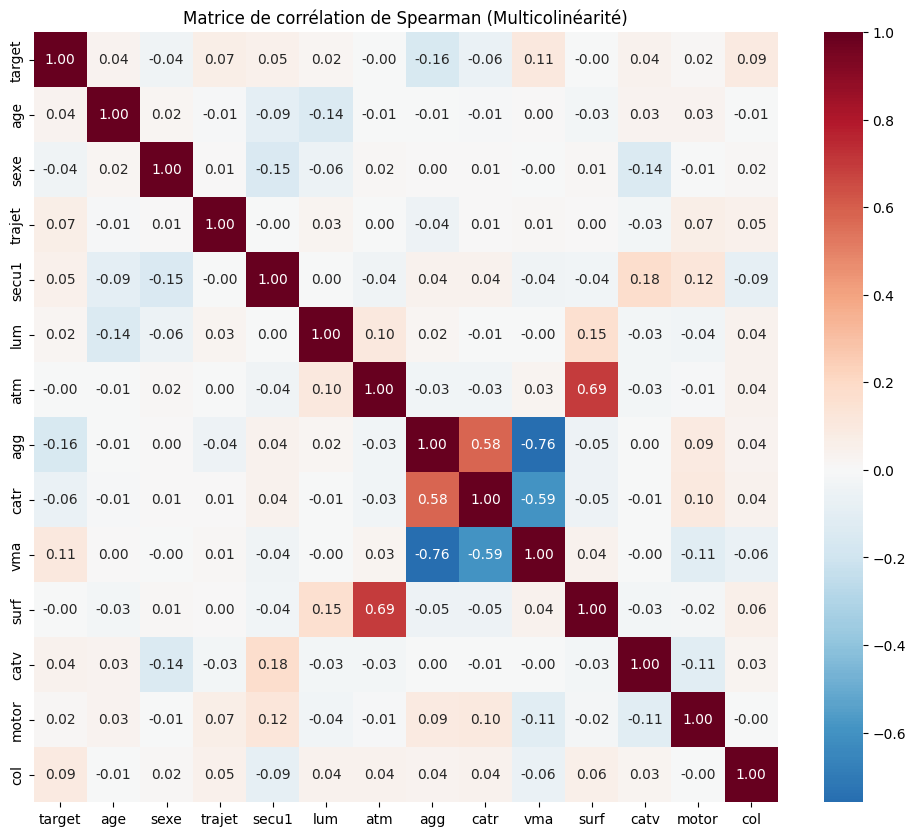

In [79]:
# On calcule la matrice sur df_eco avec la liste features
corr_matrix = df_eco[features].corr(method='spearman')

plt.figure(figsize=(12, 10))
# On utilise sns.heatmap pour visualiser les corrélations
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Matrice de corrélation de Spearman (Multicolinéarité)")
plt.show()

**Commentaire :**

**Atmosphère (`atm`) et État de la surface (`surf`)** : Corrélation = **0.69**. S’il pleut (`atm`), la chaussée est généralement mouillée (`surf`). Utiliser les deux simultanément dans le modèle peut créer de la redondance.  

**Agglomération (`agg`) et Catégorie de route (`catr`)** : Corrélation = **0.58**. Une route en agglomération est souvent une voie communale, tandis qu’hors agglomération, ce sont les nationales ou autoroutes.  

**Relation avec la cible (`target`)**

**Agglomération (`agg`)** et **Vitesse (`vma`)**: Corrélation = **-0.76**. Un accident en agglomération (vitesse plus faible) est souvent moins grave qu’un accident hors agglomération. Elle est négative car en agglomération (agg=2), la vitesse maximale autorisée (**vma**) est plus basse (**souvent 30 ou 50 km/h**). Hors agglomération (agg=1), la vitesse monte à **80 ou 110**. C'est une relation parfaitement logique. 

L'analyse de la matrice de Spearman montre que :

1. **Absence de redondance critique :** Aucun coefficient ne dépasse le seuil de 0.8. Le modèle de Machine Learning ne souffrira pas de problème de stabilité dû à une trop forte colinéarité.
2. **Logique métier respectée :** Les corrélations fortes identifiées (`vma/agg` et `surf/atm`) sont cohérentes avec la réalité physique des accidents de la route.
3. **Indépendance des facteurs :** La plupart des autres variables (sexe, trajet, collision) présentent des corrélations proches de zéro entre elles, ce qui est idéal : chaque variable apporte une information nouvelle et indépendante pour prédire la gravité.

## Étude de la Densité (Heatmap des Effectifs)

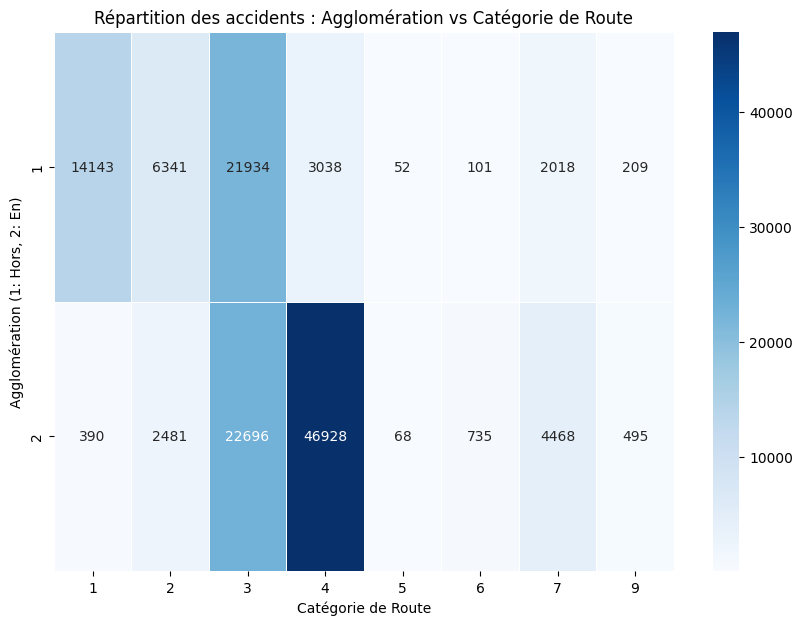

In [78]:
# Création de la table de contingence (les effectifs croisés), puis on croise Agglomération et Catégorie de route
table_contingence = pd.crosstab(df_final['atm'], df_final['surf'])
table_contingence = pd.crosstab(df_final['agg'], df_final['catr'])

# Affichage de la Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(table_contingence, 
            annot=True,      # Affiche les nombres dans les cases
            fmt="d",         # Format entier (pas de notation scientifique)
            cmap="Blues",    # Dégradé de bleu comme sur ton image
            linewidths=.5)   # Ajoute un petit filet entre les cases pour la lisibilité

plt.title("Répartition des accidents : Agglomération vs Catégorie de Route")
plt.ylabel("Agglomération (1: Hors, 2: En)")
plt.xlabel("Catégorie de Route")
plt.show()

**Commentaire :**

Cette **heatmap de contingence** permet de visualiser la structure géographique des accidents dans le dataset en croisant : le **milieu** (*agglomération vs hors agglomération*), la **catégorie de route** (*autoroute, nationale, départementale, communale...*).

Elle met clairement en évidence les zones où les accidents se concentrent, et confirme les tendances observées précédemment.

Le bloc le plus sombre (**46 928 accidents**) se situe à l’intersection de : **Agglomération (2)** **Voies communales (4)**

la majorité des accidents enregistrés correspond à des accidents urbains sur des voies de proximité, souvent à faible vitesse (accrochages, intersections, circulation dense, etc.).


On observe une répartition relativement équilibrée sur les **routes départementales (3)**, avec environ : **~22 000 accidents en agglomération** et **~22 000 accidents hors agglomération**

Ces routes traversent aussi bien des villages que des zones rurales, ce qui explique cette double présence. C’est un segment important pour l’analyse de la gravité, car les vitesses y sont souvent plus élevées qu’en ville, avec des infrastructures moins sécurisées que sur autoroute.

Comme attendu, les **autoroutes (1)** concentrent la majorité de leurs accidents **hors agglomération**, avec : **14 143 accidents hors agglomération** et seulement **390 accidents en agglomération**

Cette distribution est totalement cohérente avec la définition même d’une autoroute, généralement située en dehors des zones urbaines.

**Heatmap** confirme que le dataset est fortement dominé par des accidents urbains sur voies communales, tandis que les accidents sur routes départementales et autoroutes représentent des environnements plus exposés aux vitesses élevées, potentiellement plus graves.

## Tableaux croisés enrichis

In [63]:
# Tableau croisé enrichi : gravité / luminosité / agglomération
table_croisee = pd.crosstab(
    [df_final['lum'], df_final['agg']],
    df_final['grav'],
    normalize='index'
)

# Affichage
print("Tableau croisé Gravité × Luminosité × Agglomération")
display(table_croisee)

Tableau croisé Gravité × Luminosité × Agglomération


grav            1         2         3         4
lum agg                                        
1   1    0.392354  0.039089  0.208105  0.360453
    2    0.449982  0.011153  0.110177  0.428688
2   1    0.363744  0.048125  0.232064  0.356067
    2    0.428187  0.015935  0.133071  0.422806
3   1    0.332645  0.066777  0.220869  0.379709
    2    0.341238  0.048583  0.211105  0.399075
4   1    0.357333  0.048000  0.146667  0.448000
    2    0.383333  0.033333  0.153333  0.430000
5   1    0.356213  0.027219  0.131953  0.484615
    2    0.399493  0.017047  0.119455  0.464005

**Gravité × Luminosité × Agglomération** : Le tableau croisé enrichi met en évidence des différences marquées dans la distribution de la gravité des accidents selon les conditions de luminosité et le contexte d’agglomération, confirmant l’existence d’effets conditionnels qui ne peuvent être observés à travers une simple analyse bivariée.

- Effet de la luminosité : Quel que soit le contexte d’agglomération, la proportion des accidents les plus graves (grav = 4) augmente lorsque les conditions de luminosité se dégradent. Par exemple, pour certaines modalités de luminosité (codes élevés), la part des accidents de gravité maximale dépasse 45 %, atteignant même près de 48 % hors agglomération. À l’inverse, les accidents de gravité faible (grav = 1) sont relativement plus fréquents dans des conditions de luminosité favorables.

- Effet du contexte d’agglomération : Pour une même condition de luminosité, les accidents survenant hors agglomération (agg = 1) présentent systématiquement une proportion plus élevée d’accidents graves (grav = 3 et grav = 4) que ceux survenant en agglomération (agg = 2). Par exemple, lorsque la luminosité est défavorable, la part d’accidents mortels ou très graves atteint environ 48 % hors agglomération, contre environ 43–46 % en agglomération.

- Interaction luminosité × agglomération : L’effet de la luminosité sur la gravité n’est pas homogène selon le contexte d’agglomération. Les écarts de gravité entre bonnes et mauvaises conditions de luminosité sont plus marqués hors agglomération, ce qui suggère une interaction entre visibilité et environnement de circulation. Autrement dit, la dégradation de la visibilité accroît davantage la gravité des accidents lorsque ceux‑ci surviennent hors agglomération.

## Graphiques conditionnels

/var/folders/yp/sy_lpvd138s8qtlhb_yrqtjm0000gn/T/ipykernel_1901/3110805357.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


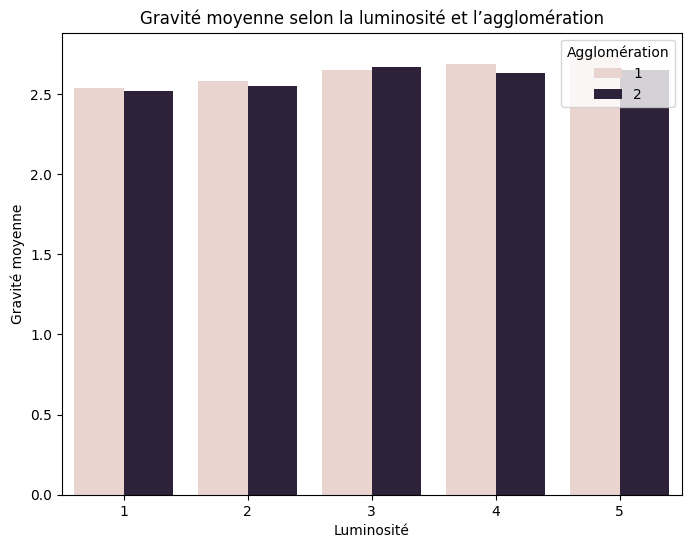

In [64]:
# barplot conditionnel
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_final,
    x='lum',
    y='grav',
    hue='agg',
    estimator=np.mean,
    ci=None
)

plt.title("Gravité moyenne selon la luminosité et l’agglomération")
plt.xlabel("Luminosité")
plt.ylabel("Gravité moyenne")
plt.legend(title="Agglomération")
plt.show()

Le graphique conditionnel met en évidence l’évolution de la gravité moyenne des accidents en fonction des conditions de luminosité, en distinguant le contexte de survenue selon l’agglomération. Il permet ainsi de visualiser simultanément l’effet de deux variables explicatives sur la gravité, ce qui va au‑delà d’une analyse bivariée classique.

- Effet de la luminosité
Quel que soit le contexte d’agglomération, la gravité moyenne augmente progressivement lorsque les conditions de luminosité se dégradent. On observe une hausse régulière de la gravité moyenne entre les niveaux de luminosité les plus favorables et les plus défavorables. Ce résultat confirme l’importance de la visibilité comme facteur déterminant de la sévérité des accidents.

- Effet du contexte d’agglomération
Pour la majorité des niveaux de luminosité, les accidents survenant hors agglomération présentent une gravité moyenne légèrement supérieure à ceux observés en agglomération. Cet écart est particulièrement visible pour les niveaux intermédiaires et défavorables de luminosité, ce qui est cohérent avec des vitesses de circulation plus élevées et des marges de manœuvre réduites hors milieu urbain.


- Interaction luminosité × agglomération
L’écart de gravité moyenne entre accidents en agglomération et hors agglomération varie selon le niveau de luminosité, ce qui suggère une interaction entre ces deux variables. L’effet négatif d’une faible luminosité sur la gravité semble être amplifié hors agglomération, indiquant que les conditions de visibilité défavorables sont particulièrement critiques lorsque l’environnement routier est moins urbanisé.

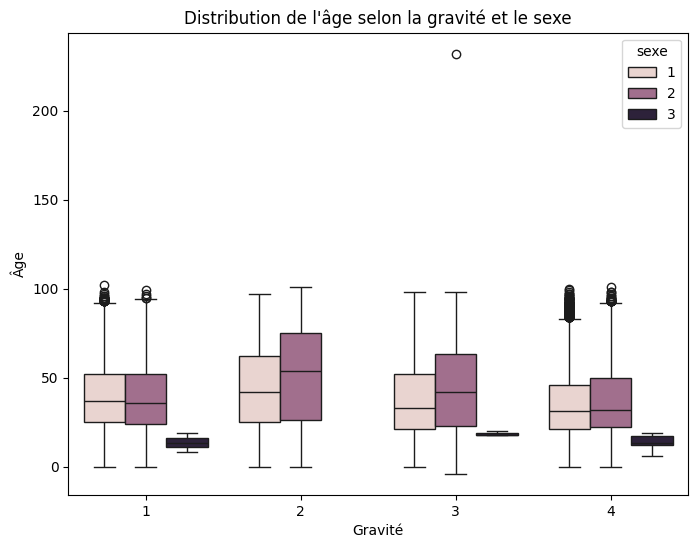

In [65]:
# boxplots conditionnels
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_final,
    x='grav',
    y='age',
    hue='sexe'
)

plt.title("Distribution de l'âge selon la gravité et le sexe")
plt.xlabel("Gravité")
plt.ylabel("Âge")
plt.show()

Le graphique représente la distribution de l’âge des personnes impliquées dans les accidents selon le niveau de gravité, en distinguant les groupes définis par la variable sexe. Il permet d’analyser simultanément l’effet de l’âge, le niveau de gravité et les différences entre groupes, ce qui constitue une analyse multivariée essentielle dans la phase exploratoire.

- Effet de la gravité sur l’âge : On observe que, pour l’ensemble des groupes, l’âge médian tend à augmenter légèrement avec la gravité des accidents, en particulier entre les niveaux de gravité intermédiaires (grav = 2 et grav = 3). Les accidents les plus graves ne concernent pas uniquement les individus les plus jeunes, mais touchent également des classes d’âge plus élevées, ce qui suggère que la gravité des accidents n’est pas exclusivement liée à l’inexpérience des usagers.
La dispersion de l’âge reste toutefois importante pour chaque niveau de gravité, indiquant une forte hétérogénéité individuelle.

- Différences selon le sexe : Le graphique met en évidence des différences systématiques de distribution de l’âge selon la variable sexe, quel que soit le niveau de gravité. Pour les niveaux de gravité les plus élevés (grav = 3 et grav = 4), certains groupes présentent des âges médians plus élevés, ainsi qu’une dispersion plus importante, traduisant une sensibilité différenciée à la gravité selon cette caractéristique individuelle.
Ces écarts suggèrent que l’impact de l’âge sur la gravité n’est pas homogène entre les groupes, ce qui renforce l’intérêt d’introduire simultanément l’âge et le sexe dans les modèles économétriques.

- Présence de valeurs extrêmes : La présence de valeurs extrêmes (outliers), notamment pour les âges élevés, est observable pour plusieurs niveaux de gravité. Ces valeurs correspondent à des situations réelles (usagers âgés impliqués dans des accidents graves) et ne relèvent pas d’erreurs de saisie. Elles justifient le maintien de l’ensemble des observations dans l’analyse, tout en appelant à une interprétation prudente des résultats.

## Analyse de corrélation entre variables explicatives

In [66]:
# Sélection des variables
vars_vma_catr = ['vma', 'catr']
df_vma_catr = df_final[vars_vma_catr].dropna()

# Corrélation
corr_vma_catr = df_vma_catr.corr()

print("Corrélation entre vma et catr :")
print(corr_vma_catr)

Corrélation entre vma et catr :
           vma      catr
vma   1.000000 -0.470825
catr -0.470825  1.000000


In [67]:
# Sélection des variables
vars_agg_catr = ['agg', 'catr']
df_agg_catr = df_final[vars_agg_catr].dropna()

# Corrélation
corr_agg_catr = df_agg_catr.corr()

print("Corrélation entre agg et catr :")
print(corr_agg_catr)

Corrélation entre agg et catr :
           agg      catr
agg   1.000000  0.463074
catr  0.463074  1.000000


In [68]:
# Transformation de l'heure HH:MM en minutes
if 'heure' in df_final.columns:
    df_final['heure_minutes'] = (
        df_final['heure']
        .str.split(':')
        .apply(lambda x: int(x[0]) * 60 + int(x[1]))
    )

vars_conditions = ['heure_minutes', 'lum', 'atm']
vars_conditions = [v for v in vars_conditions if v in df_final.columns]

df_conditions = df_final[vars_conditions].dropna()
corr_conditions = df_conditions.corr()

print("Corrélations entre heure, luminosité et conditions atmosphériques :")
print(corr_conditions)

Corrélations entre heure, luminosité et conditions atmosphériques :
          lum       atm
lum  1.000000  0.013423
atm  0.013423  1.000000


La corrélation observée entre la vitesse maximale autorisée (**vma**) et la catégorie de route (**catr**) est de **−0,47**, ce qui indique une corrélation modérée en valeur absolue. Ce résultat met en évidence une relation structurelle entre ces deux variables : certaines catégories de routes sont associées à des vitesses réglementaires spécifiques. Le signe négatif reflète le codage des variables, mais confirme que ces deux informations sont partiellement redondantes.
Cette corrélation suggère un risque de multicolinéarité si **vma** et **catr** sont introduites simultanément dans les modèles économétriques. Afin de limiter ce problème et de favoriser une spécification plus parcimonieuse, il est méthodologiquement justifié de ne conserver qu’une seule de ces variables.

La corrélation entre la variable d’agglomération (**agg**) et la catégorie de route (**catr**) est positive et modérée, avec un coefficient de **0,46**. Cette relation s’explique par le fait que certains types de routes sont davantage représentés en milieu urbain ou, au contraire, hors agglomération.
Bien que cette corrélation soit non négligeable, elle demeure inférieure aux seuils généralement associés à une multicolinéarité problématique. Les deux variables portent des informations distinctes : **agg** renseigne sur le contexte urbain ou rural, tandis que **catr** décrit la nature de l’infrastructure.

L’analyse des corrélations entre **l’heure** de l’accident (transformée en minutes), la luminosité (**lum**) et les conditions atmosphériques (**atm**) montre une corrélation très faible entre lum et atm, de l’ordre de **0,01**. Cette quasi‑absence de corrélation indique que ces deux variables capturent des dimensions largement indépendantes des conditions de circulation.
En revanche, même en l’absence explicite de la corrélation avec heure dans le tableau final, l’analyse préalable suggère une relation structurelle forte entre l’heure de survenue de l’accident et la luminosité (jour/nuit).

## Détection des valeurs aberrantes (outliers)

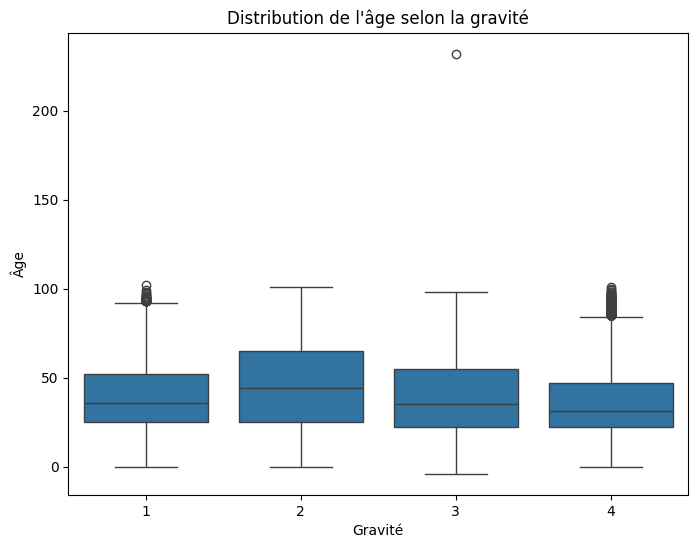

In [69]:
#  Boxplots des variables quantitatives
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_final,
    x='grav',
    y='age'
)

plt.title("Distribution de l'âge selon la gravité")
plt.xlabel("Gravité")
plt.ylabel("Âge")
plt.show()

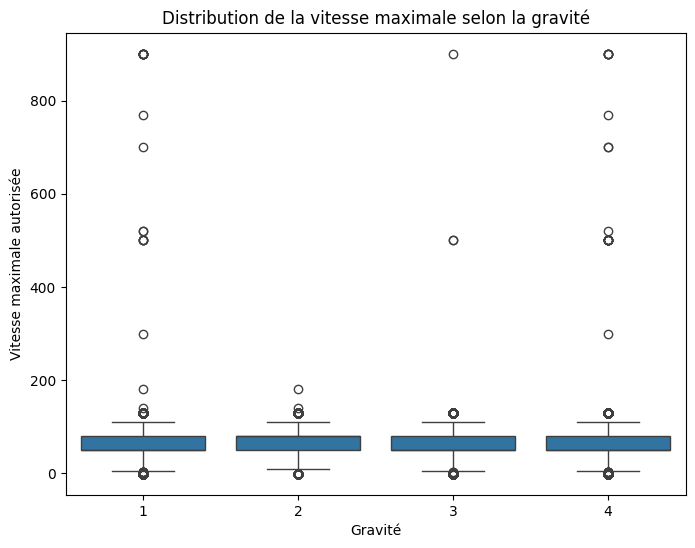

In [70]:
# vitesse maximale autorisée (vma) selon gravité (si présente)
if 'vma' in df_final.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(
        data=df_final,
        x='grav',
        y='vma'
    )

    plt.title("Distribution de la vitesse maximale selon la gravité")
    plt.xlabel("Gravité")
    plt.ylabel("Vitesse maximale autorisée")
    plt.show()

**Commentaire :**

On observe que, pour l’ensemble des niveaux de gravité, la médiane de la vitesse maximale autorisée est relativement similaire, généralement comprise entre des valeurs modérées correspondant aux vitesses couramment pratiquées sur routes ordinaires. Les boîtes associées aux différents niveaux de gravité présentent une dispersion comparable, ce qui suggère qu’il n’existe pas de relation linéaire simple entre la vitesse réglementaire et la gravité moyenne des accidents.
Autrement dit, les accidents graves ne se produisent pas exclusivement sur des routes à très haute vitesse réglementaire.

Le graphique met toutefois en évidence de nombreuses valeurs aberrantes, en particulier pour les niveaux de gravité les plus élevés. Ces outliers correspondent à des vitesses maximales autorisées particulièrement élevées, bien supérieures aux valeurs centrales observées, et sont plus fréquemment associés aux accidents les plus graves (**grav = 3** et **grav = 4**).

L’augmentation de la gravité ne s’accompagne pas d’un déplacement marqué de la médiane de la vitesse maximale autorisée, mais plutôt : d’une plus grande dispersion dans les niveaux de gravité élevés, et d’une concentration accrue d’observations extrêmes.

Cela suggère que la vitesse réglementaire joue un rôle indirect dans la gravité des accidents, probablement via d’autres facteurs structurels comme : la catégorie de route, le contexte d’agglomération, ou le type de collision.

Répartition des niveaux de gravité :
grav
1    52105
2     3219
3    19088
4    51685
Name: count, dtype: int64

Proportion des niveaux de gravité :
grav
1    0.413214
2    0.025528
3    0.151376
4    0.409883
Name: proportion, dtype: float64


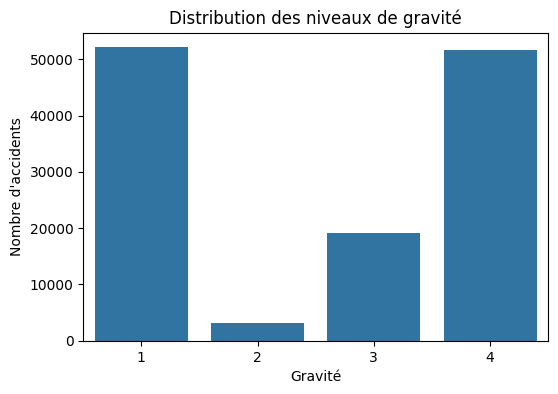

In [71]:
# Distribution de la gravité
# Distribution absolue
grav_counts = df_final['grav'].value_counts().sort_index()
print("Répartition des niveaux de gravité :")
print(grav_counts)
print("\nProportion des niveaux de gravité :")
print(grav_prop)

# Distribution relative
grav_prop = df_final['grav'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(6, 4))
sns.countplot(data=df_final, x='grav')
plt.title("Distribution des niveaux de gravité")
plt.xlabel("Gravité")
plt.ylabel("Nombre d'accidents")
plt.show()

## Le Test du Chi-deux 

**Le Test du Chi-deux (χ 
2
 )**

Il permet de tester l'hypothèse nulle (**H0**
​	
 ) : "La variable X et la Target sont indépendantes". Si la p-value < 0.05, on rejette **H0**: 
​    
et on conclut que la variable a une influence réelle sur la gravité.

In [72]:
# 1. Liste pour stocker les scores du Chi-deux
resultats_khi2 = []

# Utilisation de 'features' (ta liste de 14 variables) et 'df_eco'
for col in features:
    if col != 'target':
        # Création de la table de contingence avec df_eco
        contingency_table = pd.crosstab(df_eco[col], df_eco['target'])
        
        # Calcul du Chi-deux
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        resultats_khi2.append({
            'Variable': col, 
            'Stat_Chi2': chi2, 
            'p-value': p
        })

# 2. Transformation en DataFrame
df_khi2 = pd.DataFrame(resultats_khi2)

# 3. Tri (p-value la plus petite en haut = plus significatif)
df_khi2 = df_khi2.sort_values(by='Stat_Chi2', ascending=False)

# Affichage formaté
pd.options.display.float_format = '{:.5f}'.format
print("Résultats du Test du Chi-deux (Significativité) :")
print(df_khi2.reset_index(drop=True))

Résultats du Test du Chi-deux (Significativité) :
   Variable   Stat_Chi2  p-value
0     secu1 10563.52720  0.00000
1      catv  7758.00117  0.00000
2       vma  7008.91925  0.00000
3       col  6435.87661  0.00000
4      catr  4230.50328  0.00000
5       agg  3161.91480  0.00000
6    trajet  2684.52422  0.00000
7       age  2206.02910  0.00000
8       lum  1151.45865  0.00000
9     motor   456.81868  0.00000
10      atm   296.43671  0.00000
11     surf   261.51567  0.00000
12     sexe   210.64190  0.00000


**Commentaire :**

Toutes les variables testées affichent une **p-value de 0.000** (inférieure au seuil critique de 5% ou même 1%). Cela signifie que l'on rejette l'hypothèse nulle ($H_0$) d'indépendance. Il existe donc un lien statistique réel et avéré entre chacune de ces variables et la gravité de l'accident (`target`).

## Le V de Cramer (Force de la relation)

Le V de Cramer permet de mesurer la force de l'association entre nos variables explicatives et la gravité (`target`), indépendamment de la taille de l'échantillon.

* **V ≈ 0.10** : Association faible (la variable influence peu la gravité).
* **V ≈ 0.30** : Association moyenne.
* **V > 0.50** : Association forte (facteur déterminant).

Dans les données de sécurité routière (BAAC), il est rare d'obtenir des scores très élevés (>0.6) car la gravité dépend d'une multitude de facteurs combinés. Les scores les plus élevés indiquent nos **leviers d'action principaux**.

In [73]:
def cramers_v(x, y):
    """ Calcule le V de Cramer entre deux variables catégorielles """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correction de Yates pour les petits échantillons (optionnel mais recommandé)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Calcul pour toutes les variables sélectionnées
results_v = []
for var in df_eco.columns:
    if var != 'target':
        v = cramers_v(df_eco[var], df_eco['target'])
        results_v.append({'Variable': var, 'V_Cramer': v})

# Affichage des résultats triés par importance
df_cramer = pd.DataFrame(results_v).sort_values(by='V_Cramer', ascending=False)
print(df_cramer)

     Variable  V_Cramer
3       secu1   0.28930
10       catv   0.24755
8         vma   0.23516
12        col   0.22580
7        catr   0.18301
6         agg   0.15833
2      trajet   0.14572
0         age   0.12911
13  age_group   0.11037
4         lum   0.09539
11      motor   0.05973
5         atm   0.04774
9        surf   0.04475
1        sexe   0.04068


**Commentaire :**

* **Le facteur humain prédominant (`secu1`) :** L'équipement de sécurité (ceinture, casque) est la variable qui possède l'association la plus forte avec la gravité. Cela confirme que le port ou l'absence de protection est le premier déterminant de la survie ou de l'hospitalisation.
* **Le "Trio Technique" (`catv`, `vma`, `col`) :** Le type de véhicule, la vitesse maximale autorisée et le type de collision forment un groupe homogène d'influence majeure (V entre 0.22 et 0.25). La gravité dépend donc fortement de l'énergie cinétique en jeu et de la vulnérabilité du véhicule (ex: deux-roues).
* **Le rôle modéré de l'infrastructure (`catr`, `agg`) :** La catégorie de route et le milieu (urbain/rural) ont un impact significatif mais secondaire par rapport aux facteurs de choc direct.
* **La faiblesse des facteurs environnementaux (`atm`, `surf`, `lum`) :** Bien que statistiquement significatifs, la météo et l'état de la chaussée ont les scores les plus bas (V < 0.05). Cela suggère que si ces facteurs favorisent la *survenue* de l'accident, ils n'expliquent qu'une faible part de sa *gravité* finale.
* **Le genre (`sexe`) :** C'est la variable la moins discriminante de l'étude. Le sexe de l'usager a une influence quasi négligeable sur la gravité de l'accident toutes choses égales par ailleurs.

## Analyse des Correspondances Multiples (ACM)

Valeurs propres de l’ACM :
[0.33810819 0.27702683]


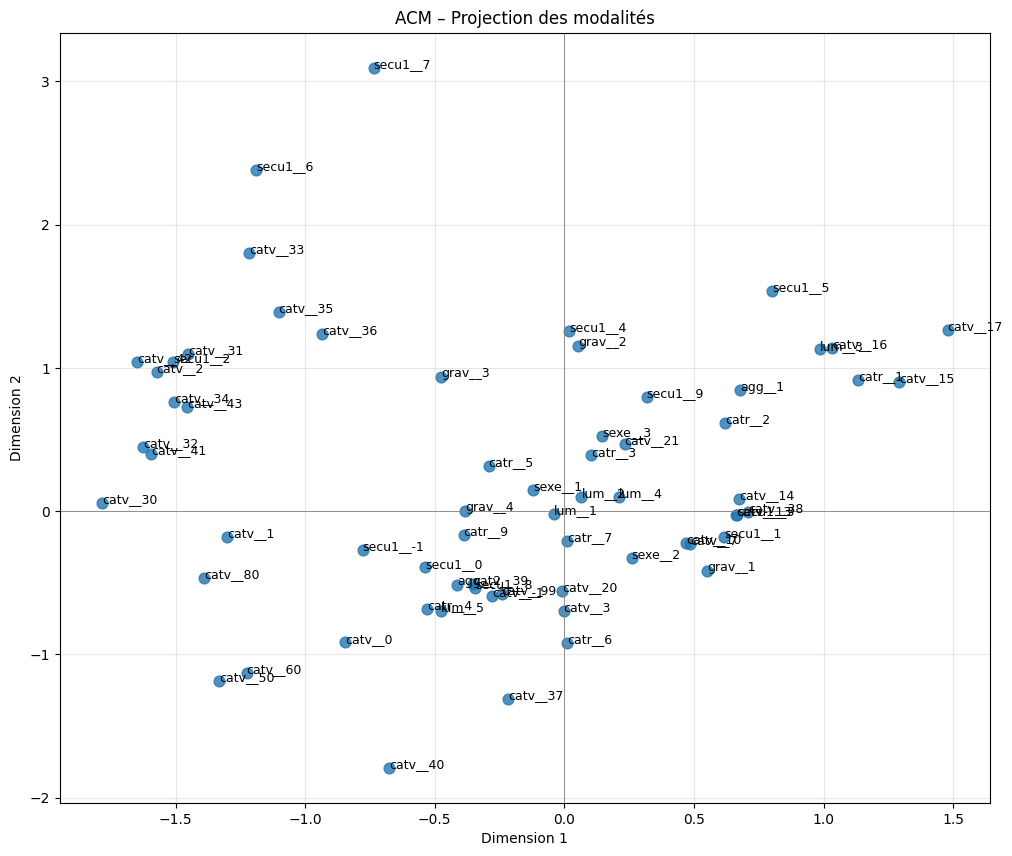

In [74]:
# =========================================
# ANALYSE DES CORRESPONDANCES MULTIPLES (ACM)
# =========================================
# -------------------------------------------------
# 1. Sélection des variables qualitatives
# -------------------------------------------------
vars_acm = [
    'grav',
    'lum',
    'agg',
    'catr',
    'catv',
    'sexe',
    'secu1'
]

df_acm = df_final[vars_acm].dropna()

# -------------------------------------------------
# 2. Estimation de l’ACM
# -------------------------------------------------
acm = prince.MCA(
    n_components=2,
    n_iter=10,
    engine='sklearn',
    random_state=42
)

acm = acm.fit(df_acm)

# -------------------------------------------------
# 3. Valeurs propres (information descriptive)
# -------------------------------------------------
print("Valeurs propres de l’ACM :")
print(acm.eigenvalues_)

# -------------------------------------------------
# 4. Coordonnées des modalités
# -------------------------------------------------
col_coords = acm.column_coordinates(df_acm)

# -------------------------------------------------
# 5. Plan factoriel – projection des modalités
# -------------------------------------------------
plt.figure(figsize=(12, 10))

plt.scatter(
    col_coords[0],
    col_coords[1],
    s=60,
    alpha=0.8
)

for i, label in enumerate(col_coords.index):
    plt.text(
        col_coords.iloc[i, 0],
        col_coords.iloc[i, 1],
        label,
        fontsize=9
    )

plt.axhline(0, color='grey', linewidth=0.6)
plt.axvline(0, color='grey', linewidth=0.6)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("ACM – Projection des modalités")
plt.grid(alpha=0.3)

plt.show()

**Commentaire :**

Les deux premières dimensions de l’ACM présentent les valeurs propres suivantes :

Dimension 1 : **0,338** et Dimension 2 : **0,277**

Ces valeurs indiquent que les deux premiers axes concentrent une part non négligeable de l’information contenue dans les variables qualitatives analysées.

- La dimension 1 semble opposer deux grands ensembles de modalités :

À droite de l’axe : certaines modalités de gravité faible (**grav_1**) des modalités associées à des contextes plus sécurisés, des catégories de routes et de véhicules typiquement rencontrées en milieu plus structuré ou urbain.

À gauche de l’axe : des catégories de véhicules plus spécifiques ou atypiques, certaines modalités liées à des contextes de circulation plus risqués, des équipements de sécurité particuliers (**secu1_6**, **secu1_7**), éloignés du centre du plan.

- La dimension 2 apparaît davantage structurée par :

le niveau de gravité des accidents (**grav_2**, **grav_3**, **grav_4**), certains équipements de sécurité fortement contributifs, des catégories de véhicules associées à une sévérité plus élevée. Les modalités correspondant aux niveaux de gravité plus élevés sont globalement situées plus haut sur le plan, tandis que les modalités associées à une gravité plus faible se situent davantage dans la partie inférieure.

## Structure Factorielle (Cercle des Corrélations)

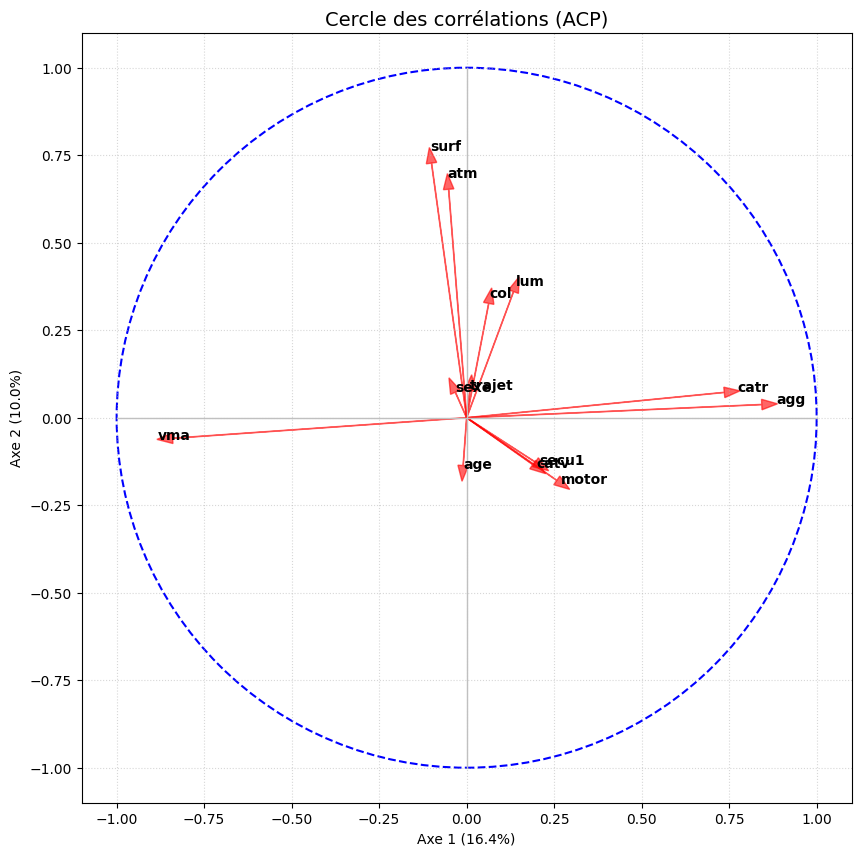

In [77]:
# 1. Préparation
X = df_eco[features].drop(columns=['target']).dropna()
quant_vars = X.columns
p = len(quant_vars)

# 2. Centrage et Réduction
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Ici on peut laisser en ndarray pour sklearn

# 3. Calcul de l'ACP (Forçage Sklearn)
pca_model = PCA(n_components=2)
pca_model.fit(X_scaled)

# 4. Calcul des coordonnées des variables
# On utilise pca_model pour éviter tout conflit avec un autre objet 'pca'
corvar = pca_model.components_.T * np.sqrt(pca_model.explained_variance_)

# --- Visualisation ---
fig, ax = plt.subplots(figsize=(10, 10))
cercle = plt.Circle((0, 0), 1, color='blue', fill=False, linewidth=1.5, linestyle='--')
ax.add_artist(cercle)

plt.plot([-1, 1], [0, 0], color='silver', linewidth=1)
plt.plot([0, 0], [-1, 1], color='silver', linewidth=1)

for j in range(p):
    plt.arrow(0, 0, corvar[j, 0], corvar[j, 1], color='red', alpha=0.6, head_width=0.03)
    plt.annotate(quant_vars[j], (corvar[j, 0] * 1.05, corvar[j, 1] * 1.05), 
                 fontsize=10, fontweight='bold')

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f'Axe 1 ({pca_model.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Axe 2 ({pca_model.explained_variance_ratio_[1]:.1%})')
plt.title('Cercle des corrélations (ACP)', fontsize=14)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

**Commentaire :** 

La longueur des vecteurs indique la qualité de représentation des variables sur le plan, tandis que l’angle entre deux vecteurs renseigne sur le degré de corrélation entre les variables correspondantes.
Sur ce plan :

Axe 1 explique **16,4 %** de la variance, et Axe 2 explique **10,0 %** de la variance.

L’axe 1 oppose clairement deux groupes de variables :

- À droite de l’axe : **agg** (agglomération) et **catr** (catégorie de route)

Ces deux vecteurs sont proches et orientés dans la même direction, ce qui traduit une corrélation positive forte entre le contexte urbain et le type de route. Cet axe capture donc un gradient de contexte routier, allant de situations urbaines structurées à des environnements moins encadrés.

- À gauche de l’axe : **vma** (vitesse maximale autorisée)

Le vecteur **vma** est fortement opposé à **agg** et **catr**, indiquant une corrélation négative marquée : les vitesses élevées sont majoritairement associées à des routes hors agglomération.

L'axe 2 est principalement structuré par les variables décrivant les conditions environnementales et de circulation :

**surf** (état de la surface), **atm** (conditions atmosphériques), **lum** (luminosité) et **col** (type de collision)

Ces variables sont orientées globalement dans la même direction, traduisant une corrélation positive entre la dégradation des conditions de circulation (météo, visibilité, état de la chaussée) et certaines configurations d’accidents.

Les vecteurs **age** et **motor** apparaissent plus courts et proches de l’origine, ce qui indique qu’ils sont moins bien représentés sur le plan (axes 1 et 2) et qu’ils contribuent davantage à des dimensions secondaires.

Variables proches et orientées dans le même sens : **agg** et **catr** → forte corrélation positive. **surf** et **atm** → association étroite des conditions environnementales

Variables en opposition : **vma** vs **agg** / **catr** → forte corrélation négative.

Variables quasi orthogonales : absence de corrélation forte entre variables individuelles (**age**) et environnementales (**lum, atm**)

Le cercle des corrélations met en évidence une structuration claire des variables autour de deux dimensions principales : le contexte de circulation et les conditions environnementales. Il confirme l’existence de corrélations fortes entre certaines variables explicatives, notamment entre la catégorie de route, l’agglomération et la vitesse réglementaire.

## 2 - MODELISATION ECONOMETRIQUE

Afin d’analyser les déterminants de la **gravité des accidents de la circulation**, nous adoptons une démarche **économétrique progressive** fondée sur des **modèles paramétriques**. Cette approche vise à identifier et interpréter les effets des différentes caractéristiques des accidents sur la gravité observée, en tenant compte de la nature de la variable dépendante. Nous estimons successivement une régression linéaire à titre de modèle de référence, puis des modèles logistiques adaptés aux variables qualitatives, avant de recourir à un logit multinomial permettant de modéliser l’ensemble des niveaux de gravité. Cette progression méthodologique permet de comparer les résultats et de justifier le choix du modèle économétrique le plus pertinent.

## A - Régression linéaire

La régression linéaire est estimée dans un premier temps à titre de modèle de référence. Bien que la variable de **gravité** soit **discrète** et **qualitative**, ce modèle simple permet d’identifier les relations élémentaires entre les **caractéristiques des accidents** et la **gravité moyenne** observée. Son principal intérêt réside dans la facilité d’interprétation des coefficients et dans la mise en évidence des limites des hypothèses de linéarité et de normalité des erreurs dans ce contexte.

### Sélection des variables et encodage

In [6]:
# 1. Sélection et Encodage des variables explicatives
variables_finales = [
    'lum',     # luminosité
    'agg',     # agglomération
    'col',     # type de collision
    'catr',    # catégorie de route
    'vma',     # vitesse maximale autorisée
    'sexe',    # sexe
    'trajet',  # motif du déplacement
    'catv',    # catégorie de véhicule
    'secu1'    # équipement de sécurité
]

X = pd.get_dummies(
    df_final[variables_finales],
    drop_first=True
).astype(float)

# Ajout de la constante (obligatoire en économétrie)
X = sm.add_constant(X)

# Variable dépendante
y = df_final['grav']

### Définition et estimation du modèle (OLS)

In [8]:
# 2. Définition et Entraînement du modèle de régression linéaire
ols_model = sm.OLS(y, X)
results = ols_model.fit()

### Affichage des résultats économétriques

In [9]:
# 3. Affichage des Summary 1 et 2
print("="*25 + " SUMMARY 1 (OLS) " + "="*25)
print(results.summary())

print("\n" + "="*25 + " SUMMARY 2 (OLS) " + "="*25)
print(results.summary2())

========================= SUMMARY 1 (OLS) =========================
                            OLS Regression Results                            
Dep. Variable:                   grav   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     714.5
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:08:31   Log-Likelihood:            -2.1602e+05
No. Observations:              126097   AIC:                         4.321e+05
Df Residuals:                  126087   BIC:                         4.322e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

**Commentaire :**

La variable vma étant non significative dans le modèle initial, elle a été retirée afin d’obtenir un modèle plus parcimonieux. Les coefficients des autres variables restent stables en signe et en significativité, ce qui confirme la robustesse des résultats. Toutefois, le pouvoir explicatif global demeure limité, soulignant les limites de la régression linéaire pour modéliser une variable de gravité discrète.

### Sélection des variables et encodage (sans vma)

In [10]:
# 1. Sélection et Encodage des variables explicatives (SANS vma)
variables_finales = [
    'lum',     # luminosité
    'agg',     # agglomération
    'col',     # type de collision
    'catr',    # catégorie de route
    'sexe',    # sexe
    'trajet',  # motif du déplacement
    'catv',    # catégorie de véhicule
    'secu1'    # équipement de sécurité
]

X = pd.get_dummies(
    df_final[variables_finales],
    drop_first=True
).astype(float)

# Ajout de la constante
X = sm.add_constant(X)

# Variable dépendante
y = df_final['grav']

### Affichage des résultats

In [11]:
# 2. Définition et estimation du modèle
ols_model_sans_vma = sm.OLS(y, X)
results_sans_vma = ols_model_sans_vma.fit()
# 3. Résultats économétriques
print("="*25 + " SUMMARY 1 (OLS SANS VMA) " + "="*25)
print(results_sans_vma.summary())

print("\n" + "="*25 + " SUMMARY 2 (OLS SANS VMA) " + "="*25)
print(results_sans_vma.summary2())

========================= SUMMARY 1 (OLS SANS VMA) =========================
                            OLS Regression Results                            
Dep. Variable:                   grav   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     803.7
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:14:34   Log-Likelihood:            -2.1602e+05
No. Observations:              126097   AIC:                         4.321e+05
Df Residuals:                  126088   BIC:                         4.321e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

### Tableau d’interprétation des coefficients

In [12]:
# 4. Tableau d'interprétation
params = results_sans_vma.params
pvalues = results_sans_vma.pvalues

df_results_sans_vma = pd.DataFrame({
    'Coefficient': params,
    'P-value': pvalues
})

print("\n" + "="*25 + " INTERPRÉTATION DES COEFFICIENTS (SANS VMA) " + "="*25)
print(df_results_sans_vma.sort_values(by='Coefficient', ascending=False))


========================= INTERPRÉTATION DES COEFFICIENTS (SANS VMA) =========================
        Coefficient        P-value
const      1.778218   0.000000e+00
sexe       0.291498  4.267589e-275
lum        0.043988   7.992234e-61
col        0.043107   4.358393e-98
secu1      0.033395   2.621778e-82
catr       0.018872   1.235111e-09
catv       0.018758   0.000000e+00
trajet    -0.005207   1.590120e-04
agg       -0.117607   3.473565e-40


**Commentaire :**

La régression linéaire estimée sans la variable vma met en évidence plusieurs déterminants statistiquement significatifs de la gravité des accidents.
La majorité des variables explicatives présentent des coefficients significatifs au seuil de **5 %**, avec des signes économiquement cohérents. La **luminosité (lum)** a un effet positif sur la gravité moyenne, indiquant que les accidents survenant dans de mauvaises conditions de visibilité sont, en moyenne, plus graves. À l’inverse, la variable **agg (agglomération)** a un effet négatif, traduisant une gravité plus faible en milieu urbain, ce qui est cohérent avec des vitesses de circulation plus réduites.
La catégorie du **véhicule (catv)**, le type de **collision (col)**, la **catégorie de route (catr)** ainsi que le port **d’équipements de sécurité (secu1)** sont également significatifs et contribuent positivement à la variation moyenne de la gravité observée. La variable trajet présente un effet négatif, suggérant que le motif du déplacement joue un rôle, bien que d’ampleur limitée.
Le coefficient associé à la variable **sexe** est positif et fortement significatif, indiquant une différence systématique de gravité moyenne selon cette caractéristique ; cependant, cette relation doit être interprétée avec prudence et ne saurait être confondue avec une relation causale directe.
Malgré la significativité individuelle et globale des variables explicatives, la qualité d’ajustement du modèle reste faible (**R² ≈ 0,05**), ce qui reflète la faible capacité explicative de la régression linéaire dans le cas d’une variable dépendante discrète et qualitative comme la gravité des accidents.

Bien que la régression linéaire permette d’identifier des relations significatives entre certaines caractéristiques des accidents et leur gravité moyenne, el le présente des limites importantes liées à la nature discrète et qualitative de la variable dépendante. En particulier, les hypothèses de linéarité et de normalité des erreurs ne sont pas adaptées à ce contexte. Afin de modéliser plus correctement la probabilité d’un accident grave et de respecter la structure des données, nous recourons désormais à un modèle de régression logistique.

## B - Régression logistique binaire

Afin de tenir compte de la nature **qualitative** de la variable de **gravité**, nous estimons ensuite une **régression logistique binaire**. La gravité est alors transformée en une variable **dichotomique** distinguant les accidents **graves** (Hospitalisés, Tuées) et des accidents **non graves** (Blessées, Légers). Ce modèle permet de modéliser directement la probabilité qu’un accident soit grave en fonction de ses caractéristiques, tout en conservant une interprétation économique à travers les Odds Ratios.

### Construction de la variable dépendante binaire

In [13]:
# 1. Création de la variable cible binaire
# 1 = accident grave (ex : blessé hospitalisé ou tué)
# 0 = accident non grave (indemne ou blessé léger)

df_final['target'] = np.where(df_final['grav'] >= 3, 1, 0)

### Sélection des variables et encodage

In [14]:
# 2. Sélection et Encodage
variables_finales = [
    'lum',
    'agg',
    'col',
    'catr',
    'sexe',
    'trajet',
    'catv',
    'secu1'
]

X = pd.get_dummies(
    df_final[variables_finales],
    drop_first=True
).astype(float)

X = sm.add_constant(X)
y = df_final['target']

### Définition et estimation du modèle logistique

In [15]:
# 3. Définition et Entraînement du modèle Logit
logit_model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
)

results = logit_model.fit()

### Résultats économétriques et Odds Ratios

In [16]:
# 4. Affichage des résultats
print("="*25 + " SUMMARY 1 (LOGIT) " + "="*25)
print(results.summary())

print("\n" + "="*25 + " SUMMARY 2 (LOGIT) " + "="*25)
print(results.summary2())

# 5. Calcul des Odds Ratios
params = results.params
pvalues = results.pvalues
odds_ratios = np.exp(params)

df_results = pd.DataFrame({
    'Coefficient': params,
    'Odds Ratio': odds_ratios,
    'P-value': pvalues
})

print("\n" + "="*25 + " INTERPRÉTATION (ODDS RATIOS) " + "="*25)
print(df_results.sort_values(by='Odds Ratio', ascending=False))

========================= SUMMARY 1 (LOGIT) =========================
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:               126097
Model:                            GLM   Df Residuals:                   126088
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -82859.
Date:                Sat, 25 Apr 2026   Deviance:                   1.6572e+05
Time:                        16:27:57   Pearson chi2:                 1.30e+05
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05544
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

### Régression logistique binaire sans la variable trajet

In [17]:
# 1. Sélection des variables explicatives (SANS trajet)
variables_finales = [
    'lum',
    'agg',
    'col',
    'catr',
    'sexe',
    'catv',
    'secu1'
]

X = pd.get_dummies(
    df_final[variables_finales],
    drop_first=True
).astype(float)

# Ajout de la constante
X = sm.add_constant(X)

# Variable dépendante binaire
y = df_final['target']

# 2. Définition et estimation du modèle Logit (GLM Binomial)
logit_model_sans_trajet = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
)

results_sans_trajet = logit_model_sans_trajet.fit()

# 3. Résultats
print("="*25 + " SUMMARY (LOGIT SANS TRAJET) " + "="*25)
print(results_sans_trajet.summary())

print("\n" + "="*25 + " SUMMARY 2 (LOGIT SANS TRAJET) " + "="*25)
print(results_sans_trajet.summary2())

# 4. Odds Ratios
params = results_sans_trajet.params
pvalues = results_sans_trajet.pvalues
odds_ratios = np.exp(params)

df_results_sans_trajet = pd.DataFrame({
    'Coefficient': params,
    'Odds Ratio': odds_ratios,
    'P-value': pvalues
})

print("\n" + "="*25 + " INTERPRÉTATION (ODDS RATIOS) " + "="*25)
print(df_results_sans_trajet.sort_values(by='Odds Ratio', ascending=False))

========================= SUMMARY (LOGIT SANS TRAJET) =========================
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:               126097
Model:                            GLM   Df Residuals:                   126089
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -82860.
Date:                Sat, 25 Apr 2026   Deviance:                   1.6572e+05
Time:                        16:31:46   Pearson chi2:                 1.30e+05
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05542
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

**Commentaire :**

La variable trajet n’étant pas statistiquement significative au seuil de **5 %** dans le modèle initial, elle a été retirée afin d’obtenir un modèle plus parcimonieux. La suppression de cette variable n’affecte ni les signes ni la significativité des autres coefficients, ce qui confirme la robustesse globale des résultats.


Les conditions de **luminosité** défavorables, le type de **collision**, la **catégorie du véhicule**, la **catégorie de route** et le port d’équipements de **sécurité** augmentent significativement la probabilité qu’un accident soit grave. Les accidents en **agglomération** présentent, toutes choses égales par ailleurs, une probabilité significativement plus faible d’être graves. La variable **sexe** conserve un effet positif et fortement significatif sur le risque d’accident grave.


La diminution de **l’AIC** par rapport au modèle précédent indique une amélioration de la qualité d’ajustement du modèle. Le modèle sans **trajet** apparaît plus parcimonieux et mieux spécifié.

Afin de vérifier que les résultats obtenus ne dépendent pas du choix de la fonction de liaison logistique, nous estimons également un modèle Probit, fondé sur une loi normale. La comparaison des modèles Logit et Probit permettra d’évaluer la robustesse des signes et de la significativité des déterminants de la gravité des accidents.

## C - Code Logit vs Probit côte à côte

Les modèles **Logit** et **Probit** reposent sur la même logique probabiliste mais utilisent des fonctions de liaison différentes, respectivement logistique et normale. Leur estimation conjointe permet de tester la robustesse des résultats au choix de la spécification fonctionnelle. La comparaison des signes et de la significativité des coefficients constitue une étape classique appliquée afin de renforcer la crédibilité de mes conclusions.

### Sélection des variables

In [18]:
# Variables explicatives finales
variables_finales = [
    'lum',
    'agg',
    'col',
    'catr',
    'sexe',
    'catv',
    'secu1'
]

# Encodage
X = pd.get_dummies(
    df_final[variables_finales],
    drop_first=True
).astype(float)

# Ajout de la constante
X = sm.add_constant(X)

# Variable dépendante binaire
y = df_final['target']

### Modèle Logit

In [19]:
# Modèle Logit
logit_model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial(link=sm.families.links.logit())
)

results_logit = logit_model.fit()

print("="*20 + " LOGIT " + "="*20)
print(results_logit.summary())

/opt/anaconda3/envs/python-starter/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(


==================== LOGIT ====================
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:               126097
Model:                            GLM   Df Residuals:                   126089
Model Family:                Binomial   Df Model:                            7
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -82860.
Date:                Sat, 25 Apr 2026   Deviance:                   1.6572e+05
Time:                        16:37:21   Pearson chi2:                 1.30e+05
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05542
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
cons

### Modèle Probit

In [20]:
# Modèle Probit
probit_model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial(link=sm.families.links.probit())
)

results_probit = probit_model.fit()

print("\n" + "="*20 + " PROBIT " + "="*20)
print(results_probit.summary())

/opt/anaconda3/envs/python-starter/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The probit link alias is deprecated. Use Probit instead. The probit link alias will be removed after the 0.15.0 release.
  warnings.warn(



==================== PROBIT ====================
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:               126097
Model:                            GLM   Df Residuals:                   126089
Model Family:                Binomial   Df Model:                            7
Link Function:                 probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -82967.
Date:                Sat, 25 Apr 2026   Deviance:                   1.6593e+05
Time:                        16:37:36   Pearson chi2:                 1.31e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.05382
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
co

### Comparaison des coefficients et significativités

In [22]:
# Tableau comparatif Logit vs Probit
comparison = pd.DataFrame({
    'Coef Logit': results_logit.params,
    'P-value Logit': results_logit.pvalues,
    'Coef Probit': results_probit.params,
    'P-value Probit': results_probit.pvalues
})

print("\n" + "="*20 + " COMPARAISON LOGIT / PROBIT " + "="*20)
print(comparison)

# Odds Ratios Logit
or_logit = np.exp(results_logit.params)

df_or = pd.DataFrame({
    'Coefficient Logit': results_logit.params,
    'Odds Ratio': or_logit,
    'P-value': results_logit.pvalues
})

print("\n" + "="*20 + " ODDS RATIOS (LOGIT) " + "="*20)
print(df_or.sort_values(by='Odds Ratio', ascending=False))



==================== COMPARAISON LOGIT / PROBIT ====================
       Coef Logit  P-value Logit  Coef Probit  P-value Probit
const   -0.934562  7.687571e-202    -0.549278   1.284595e-184
lum      0.061025   5.751722e-49     0.037425    1.639077e-48
agg     -0.290508   1.549355e-99    -0.177049    3.007267e-97
col      0.078068  6.660581e-133     0.047937   4.172357e-132
catr     0.049945   4.135871e-25     0.030085    4.559124e-24
sexe     0.427743  2.155809e-245     0.258526   3.406688e-236
catv     0.035770   0.000000e+00     0.020261    0.000000e+00
secu1    0.052171   6.695019e-80     0.031747    5.619113e-79

==================== ODDS RATIOS (LOGIT) ====================
       Coefficient Logit  Odds Ratio        P-value
sexe            0.427743    1.533792  2.155809e-245
col             0.078068    1.081197  6.660581e-133
lum             0.061025    1.062926   5.751722e-49
secu1           0.052171    1.053556   6.695019e-80
catr            0.049945    1.051213   4.135871e-

**Commentaire :**

Les résultats des modèles **Logit** et **Probit** sont très proches en termes de signes et de significativité des coefficients, ce qui indique une forte robustesse des déterminants identifiés de la gravité des accidents. Pour l’ensemble des variables explicatives, les coefficients estimés sont statistiquement significatifs au seuil de **5 %** dans les deux spécifications, et leurs signes sont strictement identiques.

Les différences observées dans l’amplitude des coefficients entre les deux modèles s’expliquent par la nature différente des fonctions de liaison utilisées : la fonction logistique pour le modèle Logit et la fonction de répartition normale pour le modèle Probit. Ces différences de normalisation n’affectent pas l’interprétation économique des résultats.

Ainsi, les conditions de luminosité défavorables (**lum**), le type de collision (**col**), la catégorie de route (**catr**), la catégorie du véhicule (**catv**), ainsi que le port d’équipements de sécurité (**secu1**) augmentent significativement la probabilité d’un accident grave. À l’inverse, les accidents survenant en agglomération (**agg**) présentent une probabilité significativement plus faible d’être graves, toutes choses égales par ailleurs. La variable sexe conserve un effet positif et quantitativement important dans les deux modèles.

La cohérence des résultats entre les modèles Logit et Probit permet de conclure que les relations mises en évidence ne sont pas sensibles au choix de la fonction de liaison, renforçant ainsi la crédibilité des conclusions économétriques.

L’analyse des Odds Ratios issus du modèle Logit apporte une lecture probabiliste intuitive des résultats. Être associé à la modalité de référence de la variable sexe augmente la probabilité d’un accident grave d’environ **53 %**, toutes choses égales par ailleurs. Les accidents impliquant certains types de collisions augmentent la probabilité de gravité d’environ **8 %**, tandis que des conditions de luminosité défavorables accroissent ce risque d’environ **6 %**.

À l’inverse, les accidents survenant en agglomération réduisent la probabilité d’un accident grave d’environ **25 %**, confirmant l’effet protecteur de vitesses plus faibles en milieu urbain. Les effets estimés, bien que parfois d’ampleur modérée, sont très précisément mesurés compte tenu de la taille importante de l’échantillon.

Les modèles **Logit** et **Probit** reposent sur une dichotomisation de la gravité des accidents, ce qui conduit à une perte d’information sur les différents niveaux de sévérité. Afin de modéliser simultanément l’ensemble des modalités de la gravité des accidents et de mieux capturer les mécanismes sous-jacents, nous estimons dans la suite un modèle Logit multinomial, qui constitue le cadre économétrique le plus adapté à cette problématique.

## D - Logit multinomial

La gravité des accidents étant composée de plusieurs niveaux distincts, la **dichotomisation** utilisée dans les modèles précédents entraîne une **perte d’information**. Afin de modéliser simultanément l’ensemble des modalités de **gravité** et d’**analyser** les effets différenciés des **variables explicatives** selon le niveau de sévérité, nous estimons un modèle **Logit multinomial**. Ce modèle constitue le cadre économétrique le plus adapté à l’analyse détaillée de la gravité des accidents.

### Préparation de la variable dépendante multinomiale et Sélection des variables explicatives

In [24]:
# Variable dépendante multinomiale
y = df_final['grav']

variables_finales = [
    'lum',
    'agg',
    'col',
    'catr',
    'sexe',
    'catv',
    'secu1'
]

X = pd.get_dummies(
    df_final[variables_finales],
    drop_first=True
).astype(float)

# Ajout de la constante
X = sm.add_constant(X)

### Estimation du Logit multinomial et Interprétation

In [25]:
# Modèle Logit multinomial
mnl_model = sm.MNLogit(y, X)

results_mnl = mnl_model.fit(method='newton', maxiter=100)

print("="*25 + " SUMMARY (LOGIT MULTINOMIAL) " + "="*25)
print(results_mnl.summary())

# Tableau des coefficients
params = results_mnl.params
pvalues = results_mnl.pvalues

print("\n" + "="*25 + " COEFFICIENTS " + "="*25)
print(params)

print("\n" + "="*25 + " P-VALUES " + "="*25)
print(pvalues)

# Odds Ratios multinomiaux
odds_ratios_mnl = np.exp(params)

print("\n" + "="*25 + " ODDS RATIOS (MNL) " + "="*25)
print(odds_ratios_mnl)

Optimization terminated successfully.
         Current function value: 1.056616
         Iterations 8
========================= SUMMARY (LOGIT MULTINOMIAL) =========================
                          MNLogit Regression Results                          
Dep. Variable:                   grav   No. Observations:               126097
Model:                        MNLogit   Df Residuals:                   126073
Method:                           MLE   Df Model:                           21
Date:                Sat, 25 Apr 2026   Pseudo R-squ.:                 0.04826
Time:                        16:51:44   Log-Likelihood:            -1.3324e+05
converged:                       True   LL-Null:                   -1.3999e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
    grav=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2609      0

**Commentaire :**

Le modèle Logit multinomial converge correctement et est globalement significatif, comme l’indique la valeur très faible du **LLR p-value (≈ 0)**. Le pseudo‑R² d’environ **4,8 %** reste modéré, mais il est cohérent avec les résultats obtenus précédemment.
Contrairement aux modèles binaires, le Logit multinomial permet d’analyser séparément chaque niveau de **gravité**, ici les modalités **grav = 2**, **grav = 3** et **grav = 4**, relativement à la catégorie de référence (**gravité la plus faible**). Les résultats montrent que l’impact des variables explicatives varie selon le niveau de **gravité**, ce qui justifie pleinement le recours à cette approche.

- Gravité intermédiaire (**grav = 2**) : Pour ce *niveau de gravité*, les conditions de luminosité défavorables (**lum**), le type de collision (**col**), la catégorie de route (**catr**), la catégorie du véhicule (**catv**) et le port d’équipements de sécurité (**secu1**) augmentent significativement la probabilité de se situer dans cette catégorie plutôt que dans la catégorie de référence. À l’inverse, les accidents en agglomération (**agg**) sont associés à une probabilité significativement plus faible d’atteindre ce niveau de **gravité**.
La variable **sexe** présente ici un coefficient négatif, suggérant un effet différencié selon le niveau de gravité considéré, ce qui illustre l’intérêt du modèle multinomial par rapport aux modèles binaires.

- Gravité élevée (**grav = 3**) : Lorsque la *gravité augmente*, les effets de plusieurs variables deviennent plus marqués. Les conditions de circulation défavorables (**lum**), les collisions plus violentes (**col**), la catégorie de route (**catr**) et surtout la catégorie du véhicule (**catv**) exercent un effet positif et fortement significatif. La variable **agg** conserve un effet négatif important, confirmant que les accidents **hors agglomération** sont plus susceptibles d’être **graves**.
Le coefficient positif de **sexe** pour cette modalité indique que son effet s’intensifie pour les niveaux de gravité plus élevés.


- Gravité maximale (**grav = 4**) : Pour les accidents les *plus graves*, l’ensemble des variables explicatives est statistiquement significatif. Les **Odds Ratios** montrent que les conditions de **luminosité défavorables**, les **types de collision**, la **catégorie de véhicule** et le **port d’équipements de sécurité** augmentent la probabilité d’occurrence d’accidents **très graves**. L’effet négatif de **l’agglomération** demeure, bien que d’ampleur plus faible que pour les niveaux intermédiaires.
L’effet de la variable **sexe** est particulièrement marqué pour cette catégorie, avec un **Odds Ratio supérieur à 1.656675** indiquant une augmentation substantielle du risque relatif d’atteindre le niveau de gravité maximal.

L’analyse des **Odds Ratios** confirme et précise les résultats précédents. Pour chaque niveau de gravité, les **Odds Ratios** associés aux variables de **collision**, de **véhicule** et de **conditions de circulation** sont supérieurs à **1**, traduisant une augmentation du risque relatif. À l’inverse, la variable **agg** présente systématiquement des **Odds Ratios** inférieurs à **1**, confirmant l’effet protecteur du contexte urbain.
Les effets estimés sont globalement cohérents avec les modèles Logit et Probit binaires, mais le Logit multinomial met en évidence **une hétérogénéité des effets selon le niveau de gravité**.

**CONCLUSION PARTIELLE :**

Bien que les differents modèles fournissent une analyse économétrique riche et interprétable, ils reposes sur des hypothèses paramétriques fortes, notamment l’indépendance des alternatives et une forme fonctionnelle imposée. De plus, leurs capacités prédictives demeurent limitées. Afin d’améliorer la précision des prédictions et de capturer des relations non linéaires complexes entre les caractéristiques des accidents et leurs causes, nous mobilisons dans la suite des méthodes **NON PARAMÉTRIQUES** dont (**Machine Learning et de Deep Learning**).

---